# ASSIGNMENT 3: DATA MINING





## Import general packages and Load the dataset


In [1]:
# For data analysis
import numpy as np 
import pandas as pd 
import sklearn as sk
# For visualization
%pip install seaborn 
%pip install matplotlib
import matplotlib.pyplot as plt
import seaborn as sns 
%pip install openpyxl
# import needed libraries for decision tree and random forest
%pip install --upgrade --force-reinstall scikit-learn numpy scipy
%pip install --upgrade --force-reinstall --no-cache-dir numpy

from sklearn import tree 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier  # k-nearest neighbors
from sklearn.svm import SVC # support vector machine
from sklearn.tree import DecisionTreeClassifier # decision tree
from sklearn.ensemble import RandomForestClassifier # random forest
from sklearn.preprocessing import LabelEncoder # for encoding categorical variables
from sklearn.preprocessing import StandardScaler # for feature scaling
from sklearn.neural_network import MLPClassifier # for neural networks
from sklearn.metrics import roc_curve, auc # for ROC curve and AUC



[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
  Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached numpy-2.4.6-cp312-cp312-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached scipy-1.17.1-cp312-cp312-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached scikit_learn-1.8.0-cp312-cp312-macosx_12_0_arm64.whl (8.1 MB)
Using cached num

In [2]:
# Load the dataset 
data_path = "/Users/wendycs037/Desktop/introtoData/A3_Assignment/Assignment3-Loan-Dataset.csv"
data = pd.read_csv(data_path) 
data.head()
data.describe()

,age,income,credit_score,loan_amount,debt_to_income_pct,num_dependents,years_employed,account_balance,num_prev_loans,monthly_expenses,application_year,loan_duration_months,loan_default
count,35000.000000,32903.000000,35000.000000,35000.000000,35000.000000,33190.000000,32296.000000,32570.000000,35000.000000,31741.000000,35000.000000,35000.000000,35000.000000
mean,46.097114,58438.888733,649.565371,18452.497599,28.535350,3.002862,5.004750,9869.567989,4.501143,14654.053920,2017.640114,46.856914,0.386657
std,16.402643,38417.658943,88.796704,17312.596427,16.028251,1.992444,4.984478,16913.172180,2.876427,10694.252107,3.917405,18.212315,0.486991
min,18.000000,3363.480000,315.000000,464.580000,1.000000,0.000000,0.000000,48.310000,0.000000,784.620000,2010.000000,12.000000,0.000000
25%,32.000000,32689.345000,589.000000,7838.017500,15.980000,1.000000,1.400000,2198.040000,2.000000,7618.370000,2015.000000,36.000000,0.000000
50%,46.000000,48641.410000,650.000000,13364.605000,26.370000,3.000000,3.500000,4940.015000,5.000000,11795.690000,2018.000000,48.000000,0.000000
75%,60.000000,72965.165000,711.000000,22978.747500,39.002500,5.000000,7.000000,10968.695000,7.000000,18380.850000,2021.000000,60.000000,1.000000
max,74.000000,506270.390000,850.000000,303775.620000,93.640000,6.000000,40.000000,632157.640000,9.000000,189567.690000,2024.000000,84.000000,1.000000


## Exploratory Data Analysis EDA 

In [3]:
#Check for missing values 
missing = data.isnull().sum()
print(missing)
missing_cols = missing[missing>0]
print(missing_cols)

print()
# Target Distribution 
counts = data['loan_default'].value_counts()
print('Target Distribution:')
print(f' No Default (0): {counts[0]:,} ({counts[0]/len(data):.1%})')
print(f' Default (1): {counts[1]:,} ({counts[1]/len(data):.1%})')

age                        0
income                  2097
credit_score               0
loan_amount                0
debt_to_income_pct         0
num_dependents          1810
years_employed          2704
account_balance         2430
num_prev_loans             0
monthly_expenses        3259
gender                     0
employment_status          0
education_level         5728
loan_purpose               0
region                     0
marital_status          4216
application_year           0
loan_duration_months       0
application_date           0
loan_default               0
dtype: int64
income              2097
num_dependents      1810
years_employed      2704
account_balance     2430
monthly_expenses    3259
education_level     5728
marital_status      4216
dtype: int64

Target Distribution:
 No Default (0): 21,467 (61.3%)
 Default (1): 13,533 (38.7%)


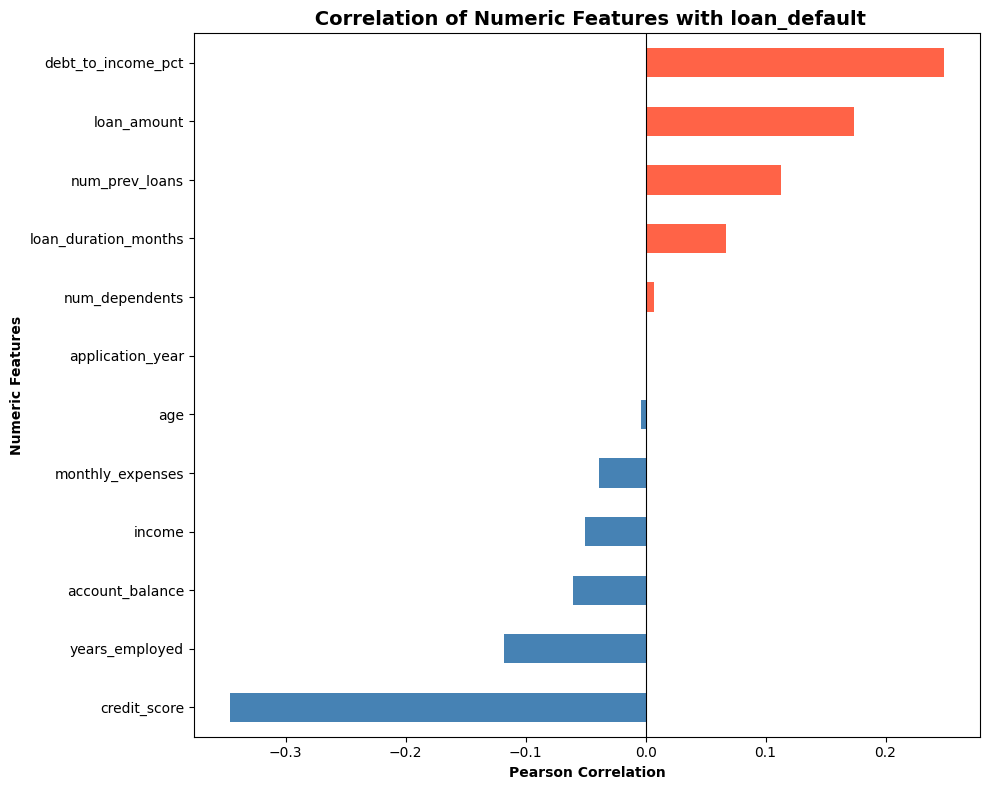

credit_score           -0.346738
years_employed         -0.117636
account_balance        -0.060085
income                 -0.050693
monthly_expenses       -0.039165
age                    -0.003674
application_year        0.001188
num_dependents          0.007335
loan_duration_months    0.067037
num_prev_loans          0.112940
loan_amount             0.173297
debt_to_income_pct      0.248929
Name: loan_default, dtype: float64


In [4]:
# Correlation of numeric features with targets
numeric_cols = data.select_dtypes(include=np.number).columns.drop('loan_default')
corr = data[list(numeric_cols) + ['loan_default']].corr()['loan_default'].drop('loan_default').sort_values()

corr.plot(kind='barh', figsize=(10,8), color=corr.map(lambda x: 'steelblue' if x <0 else 'tomato'))
plt.title(' Correlation of Numeric Features with loan_default', fontsize=14, weight='bold')
plt.xlabel('Pearson Correlation', weight='bold')
plt.ylabel('Numeric Features', weight='bold')
plt.axvline(0, color='black', linewidth = 0.8)
plt.tight_layout()
plt.show()

print(corr)

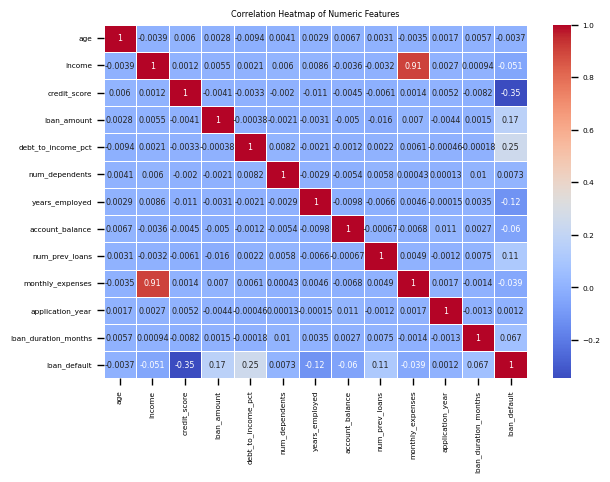

In [5]:
sns.set_context('paper', font_scale=0.6)
sns.heatmap(data.select_dtypes(include="number").corr(), annot=True, cmap='coolwarm', linewidths=0.5)
plt.figsize=(10,8)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.show()

## Key Observations from EDA 
- **`credit_score`** has the strongest negative correlation with loan_default (-0.35): higher credit score => less likely to default 
- **`debt_to_income_pct`** has the strongest positive correlation with loan_default (0.25): higher debt burdern => more likely to default 
- **`loan_amount`** and **`num_prev_loans`** are also positively correlated with loan_default (0.17 and 0.11 respectively).
- **`years_employed`** is negatively correlated with loan_default: more job stability reduces default risk. 
- Categorical features demonstrate minimal variation in loan_default rate across categories. 
 



## Data Pre-processing and Feature Engineering 

In [6]:
# preprocess() function to apply the same transformations to both training and test data
def preprocess(data, fit_medians=None, fit_columns=None): 
    #fit medians: pass in medians fitted on training data when transforming test data
    #fit_columns: pass in columns fitted on training data to align test data columns """
    data_clean = data.copy() 
    # Drop applicattion_date column (redundant with application_year) 
    # application_year already captures the useful information about the year 
    # the specific day/month is unlikely to allow models to learn meaningful patterns 
    data_clean = data_clean.drop(columns=['application_date'])
    
    # Handle missing values
    # Numeric columns: use median (robust to outliers)
    # medians are fitted only on training data to avoid data leakage 
    numeric_fill_columns = ['income', 'account_balance', 'monthly_expenses', 'num_dependents', 'years_employed']
    if fit_medians is None: 
        fit_medians = {col: data_clean[col].median() for col in numeric_fill_columns}
    for col in numeric_fill_columns: 
        data_clean[col] = data_clean[col].fillna(fit_medians[col])
    # Categorical columns: use 'Unknown' category to preserve information about missingness       
    data_clean['education_level'] = data_clean['education_level'].fillna('Unknown')
    data_clean['marital_status']  = data_clean['marital_status'].fillna('Unknown')
            
    # Ordinal Econding for Education Level: 
    # Education level has a natural order: Unknown < High School < Bachelor < Master < PhD
    education_order = {'Unknown': 0, 'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
    data_clean['education_level'] = data_clean['education_level'].map(education_order)
    
    # One-hot Encoding for Nominal Categorical Variables: 
    nominal_columns = ['gender','employment_status', 'loan_purpose', 'region', 'marital_status']
    data_clean = pd.get_dummies(data_clean, columns=nominal_columns, drop_first=True) 
    
    # Feature Engineering: Create new features capturing financial stress 
    data_clean['loan_to_income'] = data['loan_amount'] / (data['income']+1) # add 1 to avoid division by zero
    data_clean['expense_to_income'] = data['monthly_expenses'] / (data['income'] +1)
    data_clean['balance_to_loan'] = data['account_balance'] / (data['loan_amount']+1)
    # Fill any new missing values from engineered features with median 
    for col in ['loan_to_income', 'expense_to_income', 'balance_to_loan']: 
        data_clean[col]= data_clean[col].fillna(data_clean[col].median())
    
    # Align columns with training data for test/unknown data 
    if fit_columns is not None: 
        for col in fit_columns: 
            if col not in data_clean.columns: 
                data_clean[col] = 0
            data_clean = data_clean[fit_columns]
    
    return data_clean, fit_medians
        

In [7]:
# Apply preprocessing 
data_cleaned, train_medians = preprocess(data)
print(data_cleaned.shape)
print(data_cleaned.isnull().sum().sum())
print(data_cleaned.columns.tolist())

(35000, 36)
0
['age', 'income', 'credit_score', 'loan_amount', 'debt_to_income_pct', 'num_dependents', 'years_employed', 'account_balance', 'num_prev_loans', 'monthly_expenses', 'education_level', 'application_year', 'loan_duration_months', 'loan_default', 'gender_Male', 'gender_Non-Binary', 'employment_status_Part-Time', 'employment_status_Retired', 'employment_status_Self-Employed', 'employment_status_Unemployed', 'loan_purpose_Car', 'loan_purpose_Education', 'loan_purpose_Home', 'loan_purpose_Medical', 'loan_purpose_Personal', 'region_East', 'region_North', 'region_South', 'region_West', 'marital_status_Married', 'marital_status_Single', 'marital_status_Unknown', 'marital_status_Widowed', 'loan_to_income', 'expense_to_income', 'balance_to_loan']


## Dataset Split

**60% train/ 20% validation/ 20% test**
- *`Train`*: used to fit the model
- *`Validation`*: used to tune max_depth and other parameters 
- *`Test`*: evaluate final performance - simulates unseen real-world data 

In [8]:
X = data_cleaned.drop(columns=['loan_default'])
y = data_cleaned['loan_default'] 
feature_columns = X.columns.tolist()
print(X.shape)
print(y.shape)
# Split 20% test set first, then split the remaining 80% into 60% train and 20% validation
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size = 0.25, random_state=42, stratify=y_train_val 
)

print(f'Train: {len(X_train):,} samples')
print(f'Validation: {len(X_val):,} samples')
print(f'Test: {len(X_test):,} samples') 

# Scale features for distanced-based and gradient-based models 
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train) # fit only on training data 
X_val_s = scaler.transform(X_val) # transform validation data
X_test_s = scaler.transform(X_test) # transform test data

(35000, 35)
(35000,)
Train: 21,000 samples
Validation: 7,000 samples
Test: 7,000 samples


## Helper Functions to draw class metrics and ROC graphs for each model 

In [9]:
def per_class_metrics(y_true, y_pred, y_prob):
    """
    - Accuracy (overall)
    - For class 0 and class 1: Recall, Precision, F1, Sensitivity, Specificity, AUC
    """
    cr = classification_report(y_true, y_pred, output_dict=True)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Class 0 metrics
    c0 = {
        'recall':  tn / (tn + fp),          # recall for class 0
        'precision': tn / (tn + fn),          # precision for class 0
        'f1':   cr['0']['f1-score'],
        'sensitivity': tn / (tn + fp),          # sensitivity = recall for that class
        'specificity': tp / (tp + fn),          # specificity of class 0 = recall of class 1
    }
    fpr0, tpr0, _ = roc_curve(y_true, 1 - y_prob, pos_label=0)
    c0['auc'] = auc(fpr0, tpr0)
    c0['fpr'] = fpr0; c0['tpr'] = tpr0

    # Class 1 metrics
    c1 = {
        'recall':  tp / (tp + fn),          # recall for class 1
        'precision': tp / (tp + fp),          # precision for class 1
        'f1':   cr['1']['f1-score'],
        'sensitivity': tp / (tp + fn),
        'specificity': tn / (tn + fp),
    }
    fpr1, tpr1, _ = roc_curve(y_true, y_prob)
    c1['auc'] = auc(fpr1, tpr1)
    c1['fpr'] = fpr1; c1['tpr'] = tpr1

    return {
        'acc': accuracy_score(y_true, y_pred),
        'c0':  c0,
        'c1':  c1,
        'cm':  confusion_matrix(y_true, y_pred)
    }

def print_metrics_table(model_name, param_label, train_m, validation_m):
    """
    Prints the per-class metrics table exactly matching the sample report.
    Format: 0(value) and 1(value) per metric, one row per class per set.
    """
    f = lambda v: f"{v:.4f}"
    cols = ['Recall', 'Precision', 'F1 Score', 'Sensitivity', 'Specificity', 'AUC']
    keys = ['recall',    'precision',      'f1',        'sensitivity',        'specificity',        'auc']

    print(f"\n{'='*95}")
    print(f"  Training and validation Result table for {model_name}")
    print(f"{'='*95}")
    header = f"{'Parameter':<22} {'':>12}  {'Accuracy':>9}  " + \
            "  ".join(f"{c:>10}" for c in cols)
    print(header)
    print("-" * 95)

    for set_name, m in [('Training', train_m), ('Validation', validation_m)]:
        for cls in [0, 1]:
            mc = m[f'c{cls}']
            acc_str = f"{m['acc']:.4f}" if cls == 0 else ""
            row_vals = "  ".join(f"{cls}({f(mc[k])})" for k in keys)
            if cls == 0:
                print(f"  {param_label:<20} {set_name:>12}  {acc_str:>9}  {row_vals}")
            else:
                print(f"  {'':20} {'':>12}  {'':>9}  {row_vals}")
        print()
    print("  ......")
    print("=" * 95)

def plot_4_roc_curves(train_m, val_m, model_name, ax_arr):
   
    configs = [
        (ax_arr[0, 0], train_m['c0'], 'ROC curve for class 0 for training'),
        (ax_arr[0, 1], train_m['c1'], 'ROC curve for class 1 for training'),
        (ax_arr[1, 0], val_m['c0'],   'ROC curve for class 0 for validation'),
        (ax_arr[1, 1], val_m['c1'],   'ROC curve for class 1 for validation'),
    ]
    for ax, m, title in configs:
        ax.plot(m['fpr'], m['tpr'], color='red', lw=1.5,
                label=f"P(Default=1) ({m['auc']:.4f})")
        ax.plot([0, 1], [0, 1], color='gray', lw=0.8, ls='--')
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xticks(np.arange(0, 1.1, 0.1))
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.set_xlabel('False Positive Rate', fontsize=8)
        ax.set_ylabel('True Positive Rate', fontsize=8)
        ax.set_title(title, fontsize=9, pad=4)
        ax.legend(loc='lower right', fontsize=7.5)
        ax.tick_params(labelsize=7)
        ax.grid(True, alpha=0.25)


def plot_confusion_matrices(train_cm, validation_cm, model_name, ax1, ax2):
    #Side-by-side confusion matrices for training and validation.
    for ax, cm, title in [(ax1, train_cm, 'Training'), (ax2, validation_cm, 'Validation')]:
        ConfusionMatrixDisplay(cm, display_labels=['No Default 0', 'Default 1']).plot(
            ax=ax, cmap='Blues', colorbar=False)
        ax.set_title(f'Confusion Matrix ({title})', fontsize=9)


def full_model_report(model_name, param_label, train_m, validation_m, tuning_fig=None):
    
    # ── Console table ──────────────────────────────────────────────────────
    print_metrics_table(model_name, param_label, train_m, validation_m)

    #  4-panel ROC curves ───────────────────────────────────────
    fig, axes = plt.subplots(2, 2, figsize=(10, 7))
    plot_4_roc_curves(train_m, validation_m, model_name, axes)
    fig.suptitle(f'{model_name} — ROC Curves', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

    #  Confusion matrices ───────────────────────────────────────
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3.2))
    plot_confusion_matrices(train_m['cm'], validation_m['cm'], model_name, ax1, ax2)
    fig.suptitle(f'{model_name} — Confusion Matrices', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
def print_metrics_tableTest(model_name, param_label, model, X_t, y_t):
   
    y_pred = model.predict(X_t)
    y_prob = model.predict_proba(X_t)[:, 1]
    m = per_class_metrics(y_t, y_pred, y_prob)

    f = lambda v: f"{v:.4f}"
    cols = ['Recall', 'Precision', 'F1 Score', 'Sensitivity', 'Specificity', 'AUC']
    keys = ['recall',    'precision',      'f1',        'sensitivity',        'specificity',        'auc']

    print(f"\n{'='*95}")
    print(f"  Test Result table for {model_name}")
    print(f"{'='*95}")
    header = (f"{'Parameter':<22} {'':>8}  {'Accuracy':>9}  " +
              "  ".join(f"{c:>12}" for c in cols))
    print(header)
    print("-" * 95)

    for cls in [0, 1]:
        mc = m[f'c{cls}']
        row_vals = "  ".join(f"{cls}({f(mc[k])})" for k in keys)
        if cls == 0:
            print(f"  {param_label:<20} {'Test':>8}  {m['acc']:>9.4f}  {row_vals}")
        else:
            print(f"  {'':20} {'':>8}  {'':>9}  {row_vals}")

    print("=" * 95)

def plot_test_roc(model, X_t, y_t, model_name):

    y_prob = model.predict_proba(X_t)[:, 1]
    
    # Class 0 ROC
    fpr0, tpr0, _ = roc_curve(y_t, 1 - y_prob, pos_label=0)
    auc0 = auc(fpr0, tpr0)
    
    # Class 1 ROC
    fpr1, tpr1, _ = roc_curve(y_t, y_prob)
    auc1 = auc(fpr1, tpr1)

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4))
    
    for ax, fpr, tpr, roc_auc, cls in [
        (ax0, fpr0, tpr0, auc0, 0),
        (ax1, fpr1, tpr1, auc1, 1)
    ]:
        ax.plot(fpr, tpr, color='red', lw=1.5, label=f'P(Default=1) ({roc_auc:.4f})')
        ax.plot([0, 1], [0, 1], 'gray', lw=0.8, ls='--')
        ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
        ax.set_xticks(np.arange(0, 1.1, 0.1))
        ax.set_yticks(np.arange(0, 1.1, 0.1))
        ax.set_xlabel('False Positive Rate', fontsize=9)
        ax.set_ylabel('True Positive Rate', fontsize=9)
        ax.set_title(f'ROC curve for class {cls} for test', fontsize=10)
        ax.legend(loc='lower right', fontsize=8)
        ax.grid(True, alpha=0.25)

    fig.suptitle(f'{model_name} — ROC Curves (Test Set)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()  


# Model 1 - Decision Tree


### **Gini with pre-pruning**

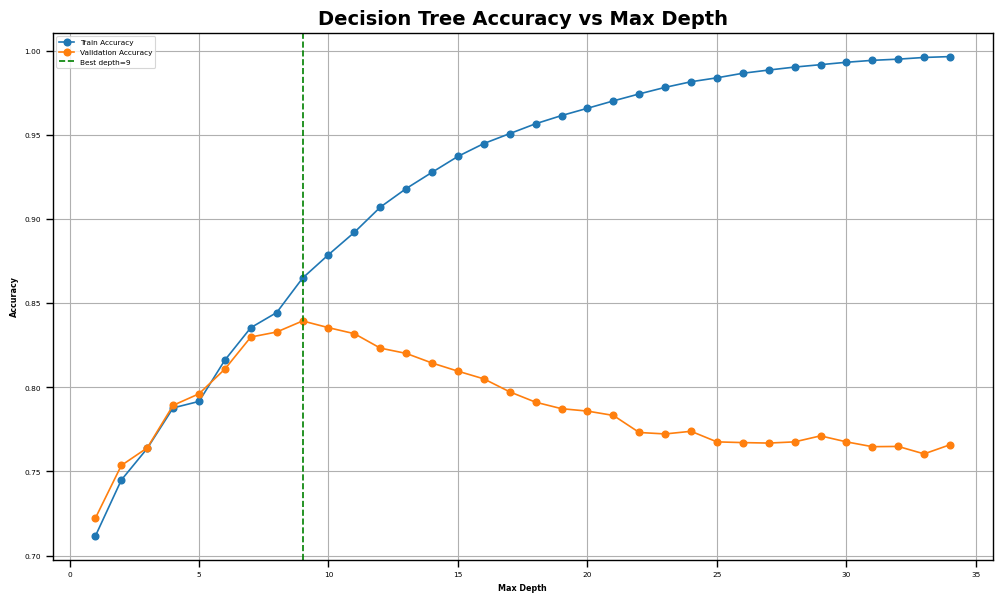

Best max_depth based on validation set: 9


In [10]:
train_scores = []
val_scores = []
depths = range(1,35) 

for d in depths: 
    dt = tree.DecisionTreeClassifier(criterion='gini',max_depth= d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    val_scores.append(accuracy_score(y_val, dt.predict(X_val)))

best_depth = depths[val_scores.index(max(val_scores))]

plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, val_scores, label='Validation Accuracy', marker='o')   
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('Max Depth', weight='bold')
plt.ylabel('Accuracy', weight='bold')
plt.title('Decision Tree Accuracy vs Max Depth', fontsize=14, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best max_depth based on validation set: {best_depth}")

In [11]:
decision_tree_modelG = tree.DecisionTreeClassifier(criterion='gini', max_depth=best_depth, random_state=42)
decision_tree_modelG.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no


  Training and validation Result table for Decision Tree
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  max_depth=9              Training     0.8649  0(0.9318)  0(0.8597)  0(0.8943)  0(0.9318)  0(0.7589)  0(0.8885)
                                                1(0.7589)  1(0.8752)  1(0.8129)  1(0.7589)  1(0.9318)  1(0.8885)

  max_depth=9            Validation     0.8394  0(0.9094)  0(0.8416)  0(0.8742)  0(0.9094)  0(0.7284)  0(0.8375)
                                                1(0.7284)  1(0.8352)  1(0.7781)  1(0.7284)  1(0.9094)  1(0.8375)

  ......


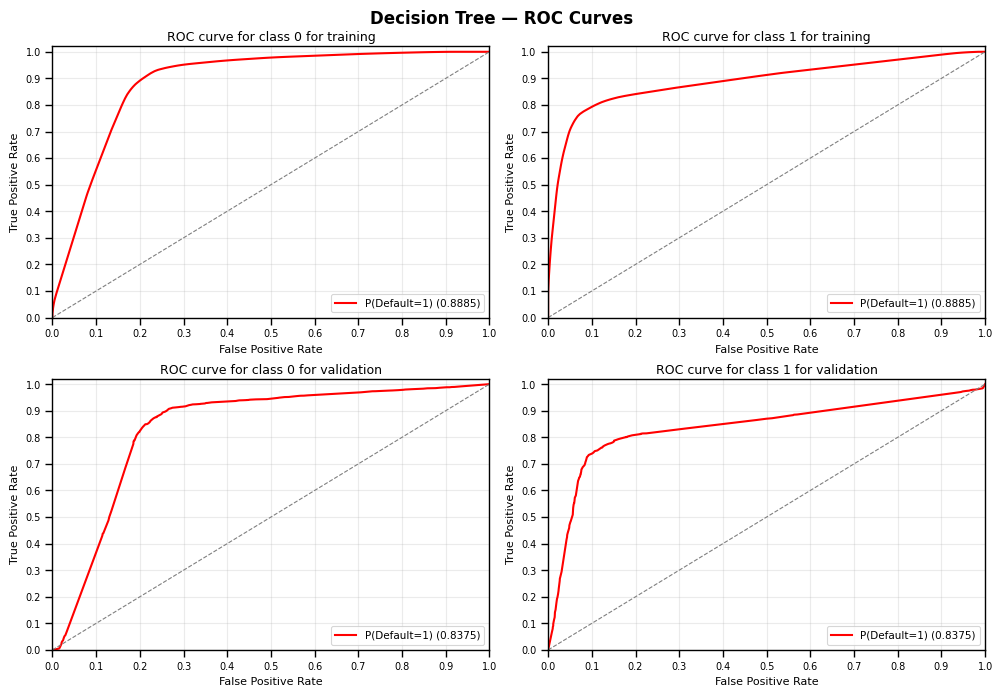

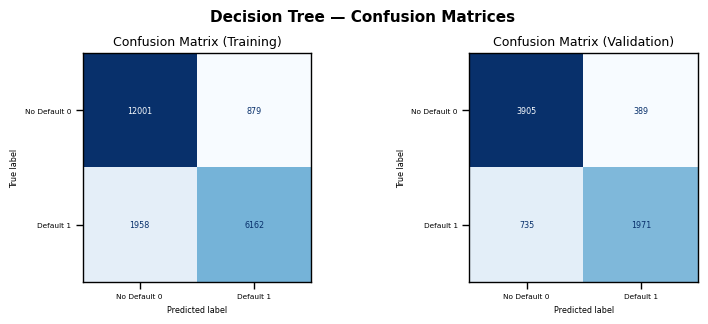

In [12]:
dt_trainG = per_class_metrics(y_train, decision_tree_modelG.predict(X_train), decision_tree_modelG.predict_proba(X_train)[:, 1])
dt_valG   = per_class_metrics(y_val,   decision_tree_modelG.predict(X_val),   decision_tree_modelG.predict_proba(X_val)[:, 1])

full_model_report('Decision Tree', f'max_depth={best_depth}', dt_trainG, dt_valG)


  Test Result table for Decision Tree (Gini)
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  max_depth=9              Test     0.8314  0(0.9068)  0(0.8331)  0(0.8684)  0(0.9068)  0(0.7119)  0(0.8331)
                                            1(0.7119)  1(0.8281)  1(0.7656)  1(0.7119)  1(0.9068)  1(0.8331)


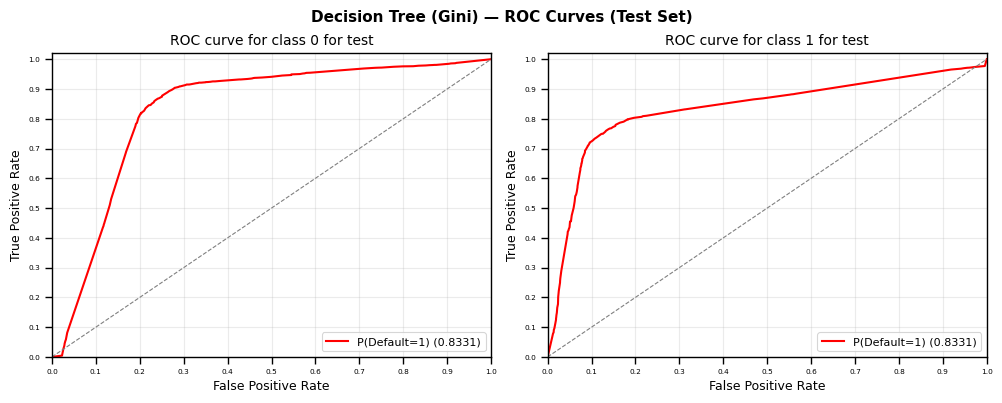

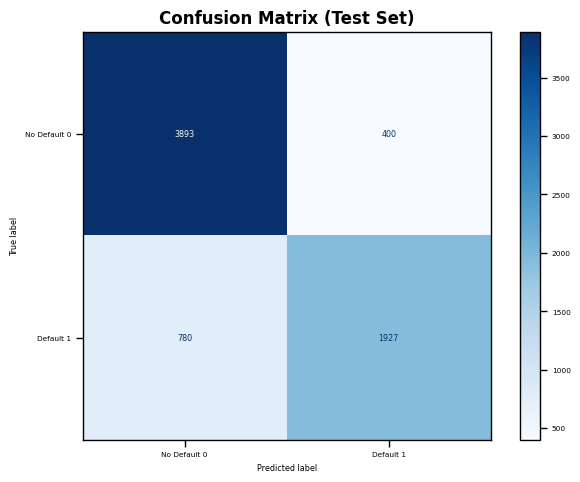

In [13]:
decision_tree_predG = decision_tree_modelG.predict(X_test)
test_mG = per_class_metrics(y_test, decision_tree_predG, decision_tree_modelG.predict_proba(X_test)[:, 1])
print_metrics_tableTest('Decision Tree (Gini)', f'max_depth={best_depth}', decision_tree_modelG, X_test, y_test)
plot_test_roc(decision_tree_modelG, X_test, y_test, 'Decision Tree (Gini)')
ConfusionMatrixDisplay(test_mG['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


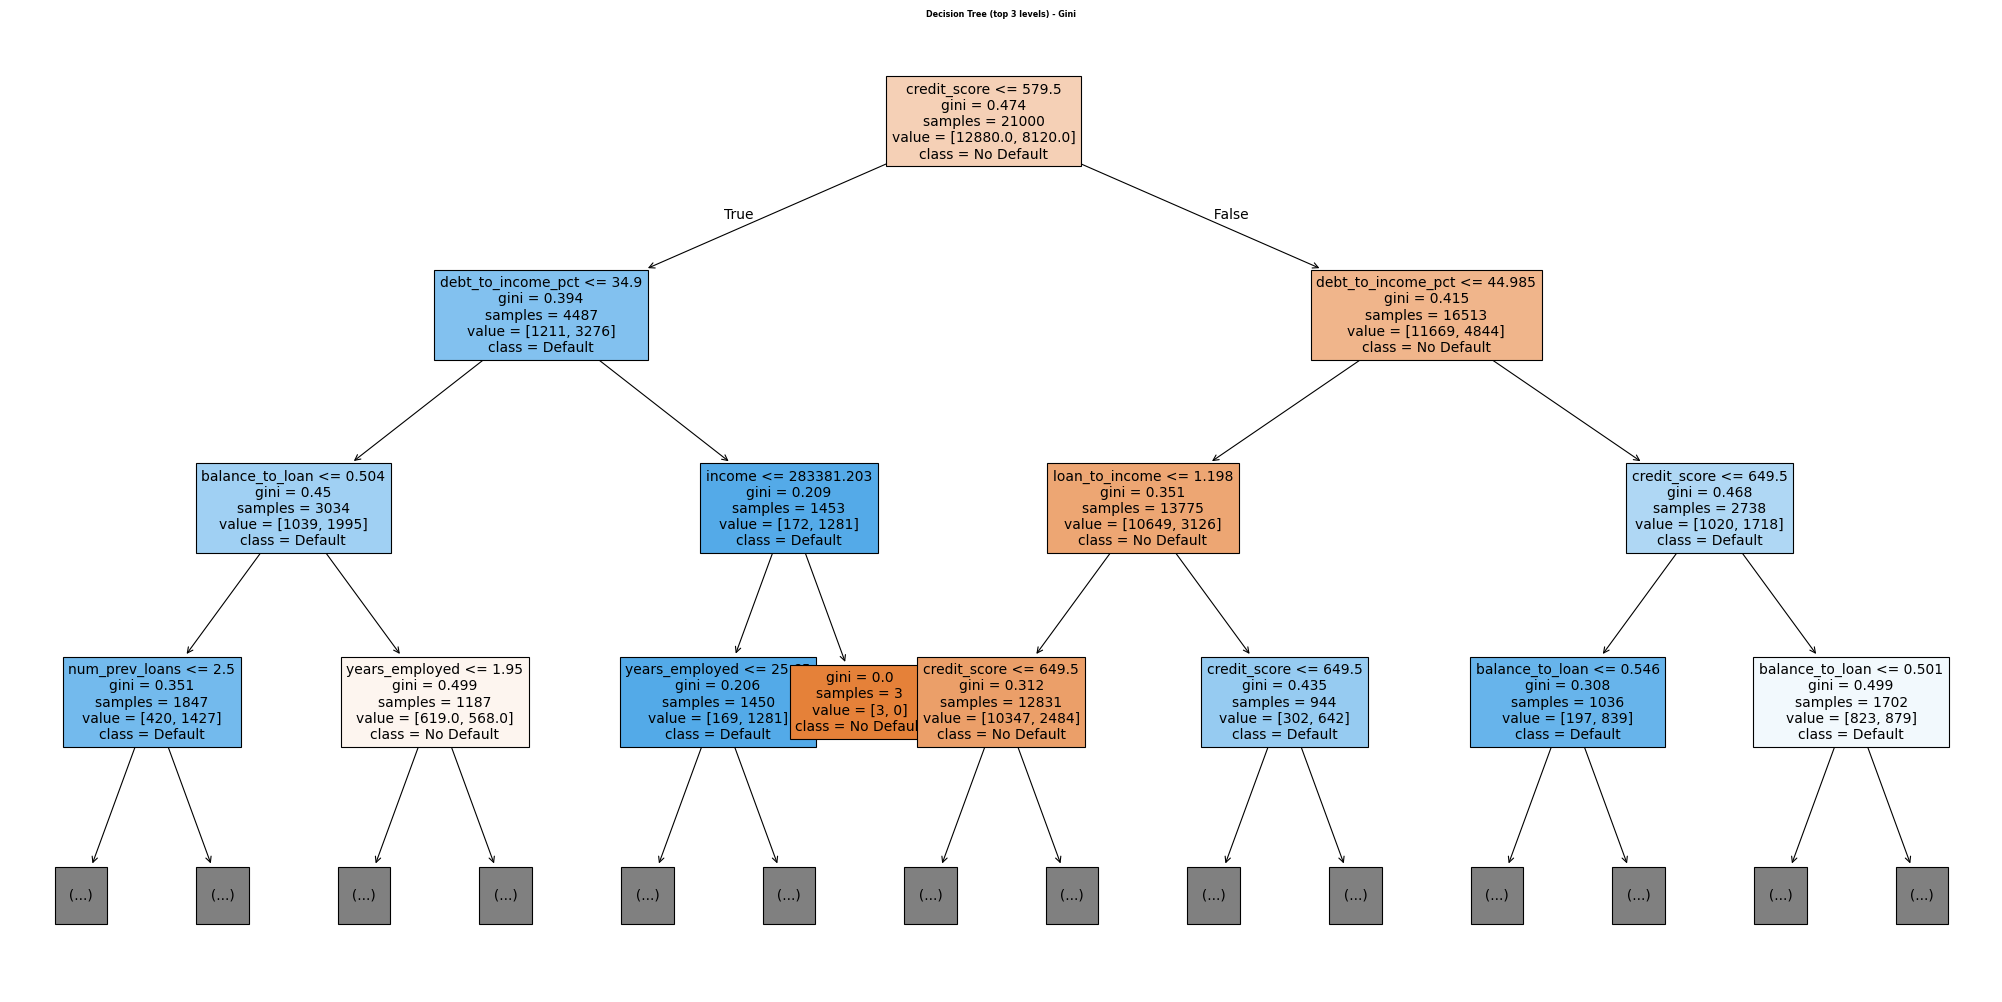

In [14]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    decision_tree_modelG, 
    feature_names=feature_columns,
    class_names=['No Default', 'Default'],
    filled = True, 
    max_depth=3, fontsize=10
)
plt.title('Decision Tree (top 3 levels) - Gini', weight='bold')
plt.tight_layout()
plt.show()

### **Gain Ratio with Pre-pruning**

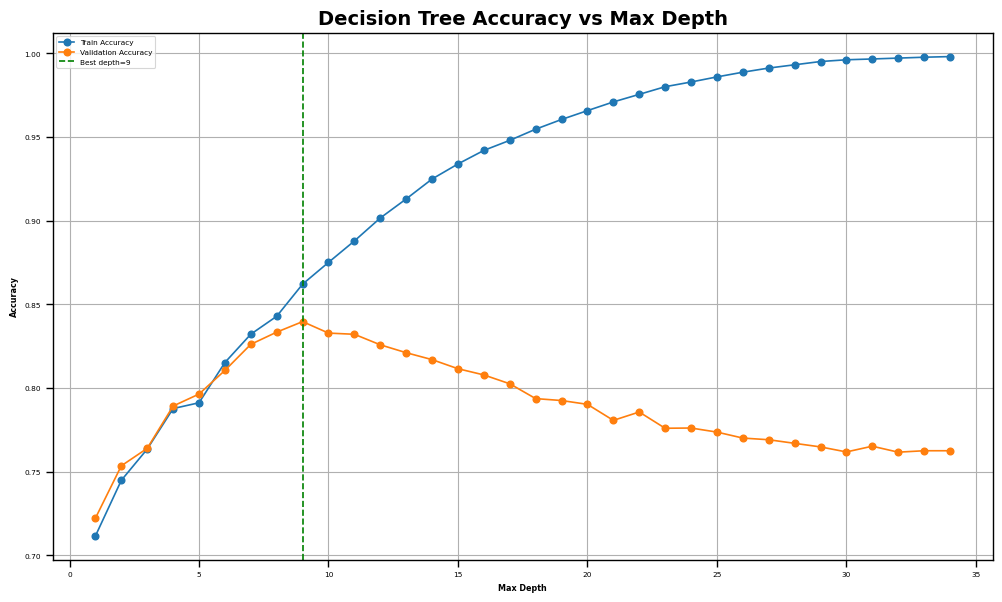

Best max_depth based on validation set: 9


In [15]:
train_scores = []
val_scores = []
depths = range(1,35) 

for d in depths: 
    dt = tree.DecisionTreeClassifier(criterion='entropy', max_depth= d, random_state=42)
    dt.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, dt.predict(X_train)))
    val_scores.append(accuracy_score(y_val, dt.predict(X_val)))

best_depth = depths[val_scores.index(max(val_scores))]

plt.figure(figsize=(10,6))
plt.plot(depths, train_scores, label='Train Accuracy', marker='o')
plt.plot(depths, val_scores, label='Validation Accuracy', marker='o')   
plt.axvline(best_depth, color='green', linestyle='--', label=f'Best depth={best_depth}')
plt.xlabel('Max Depth', weight='bold')
plt.ylabel('Accuracy', weight='bold')
plt.title('Decision Tree Accuracy vs Max Depth', fontsize=14, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f"Best max_depth based on validation set: {best_depth}")

In [16]:
decision_tree_modelE = tree.DecisionTreeClassifier(criterion='entropy',max_depth=best_depth)
decision_tree_modelE.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre


  Training and validation Result table for Decision Tree
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  max_depth=9              Training     0.8621  0(0.9318)  0(0.8562)  0(0.8924)  0(0.9318)  0(0.7517)  0(0.8925)
                                                1(0.7517)  1(0.8741)  1(0.8083)  1(0.7517)  1(0.9318)  1(0.8925)

  max_depth=9            Validation     0.8397  0(0.9110)  0(0.8409)  0(0.8746)  0(0.9110)  0(0.7265)  0(0.8393)
                                                1(0.7265)  1(0.8373)  1(0.7780)  1(0.7265)  1(0.9110)  1(0.8393)

  ......


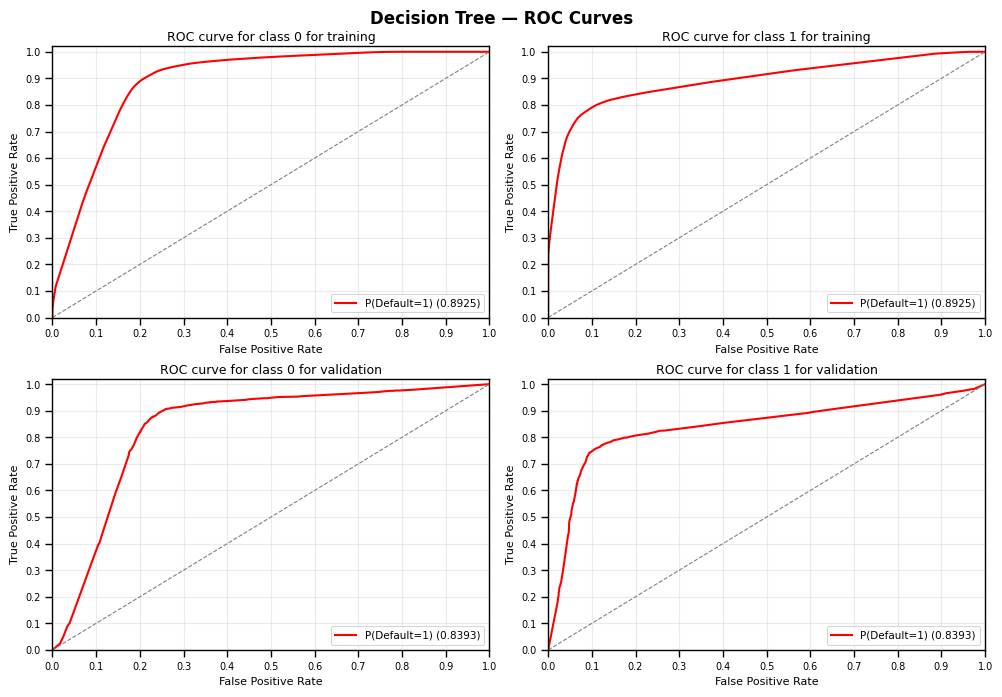

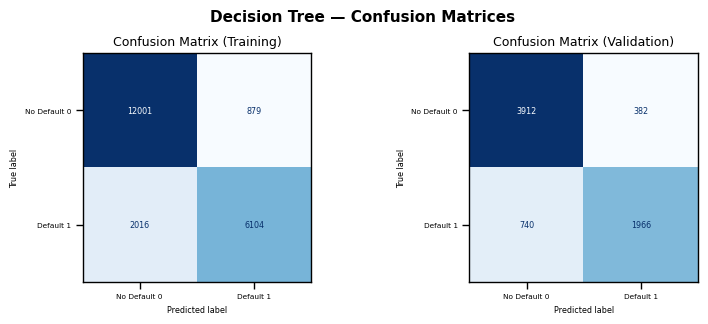

In [17]:

dt_trainE = per_class_metrics(y_train, decision_tree_modelE.predict(X_train), decision_tree_modelE.predict_proba(X_train)[:, 1])
dt_valE   = per_class_metrics(y_val,   decision_tree_modelE.predict(X_val),   decision_tree_modelE.predict_proba(X_val)[:, 1])

full_model_report('Decision Tree', f'max_depth={best_depth}', dt_trainE, dt_valE)


  Test Result table for Decision Tree (Entropy)
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  max_depth=9              Test     0.8350  0(0.9110)  0(0.8350)  0(0.8713)  0(0.9110)  0(0.7144)  0(0.8381)
                                            1(0.7144)  1(0.8351)  1(0.7701)  1(0.7144)  1(0.9110)  1(0.8381)


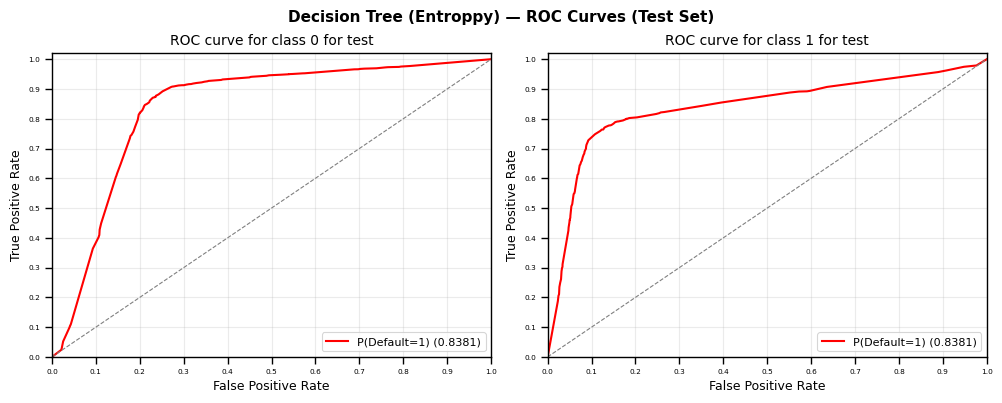

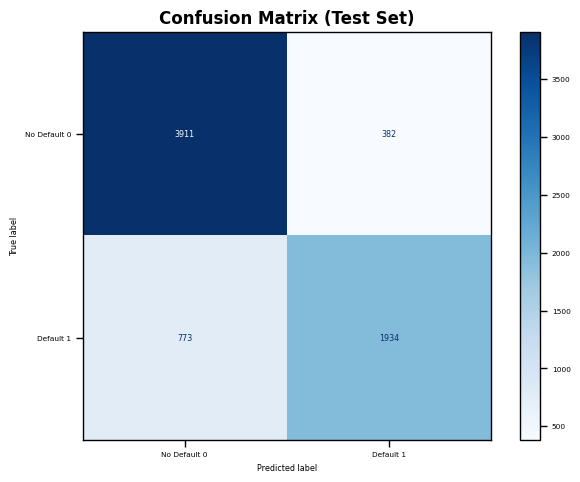

In [18]:
decision_tree_predE = decision_tree_modelE.predict(X_test)
test_mE = per_class_metrics(y_test, decision_tree_predE, decision_tree_modelE.predict_proba(X_test)[:, 1])
print_metrics_tableTest('Decision Tree (Entropy)', f'max_depth={best_depth}', decision_tree_modelE, X_test, y_test)
plot_test_roc(decision_tree_modelE, X_test, y_test, 'Decision Tree (Entroppy)')
ConfusionMatrixDisplay(test_mE['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()


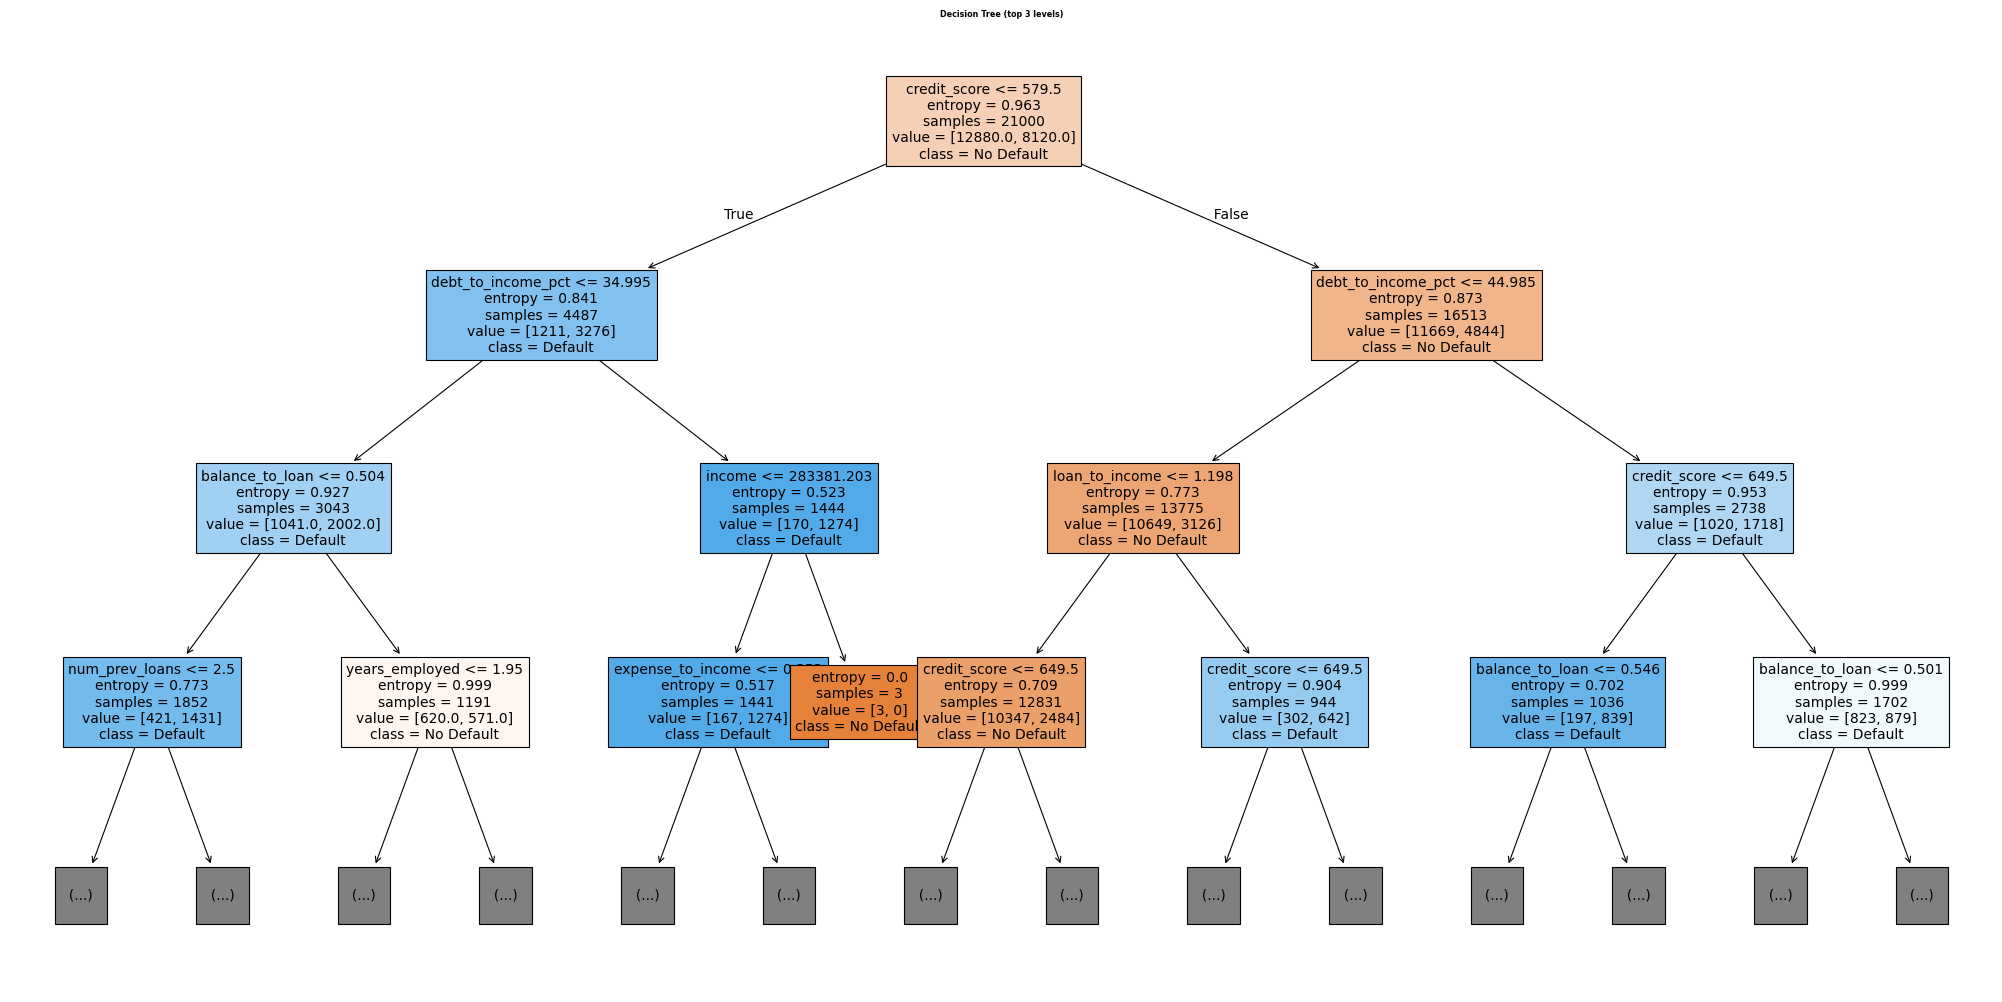

In [19]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    decision_tree_modelE,
    feature_names=feature_columns,
    class_names=['No Default', 'Default'],
    filled = True, 
    max_depth=3, fontsize=10
)
plt.title('Decision Tree (top 3 levels)', weight='bold')
plt.tight_layout()
plt.show()

# Model 2 - K-Nearest Neighbours (KNN)
- KNN classifies a point by looking at its K nearest neighbours in feature space and taking a majority vote. It requires feature scaling since it is distance-based. 

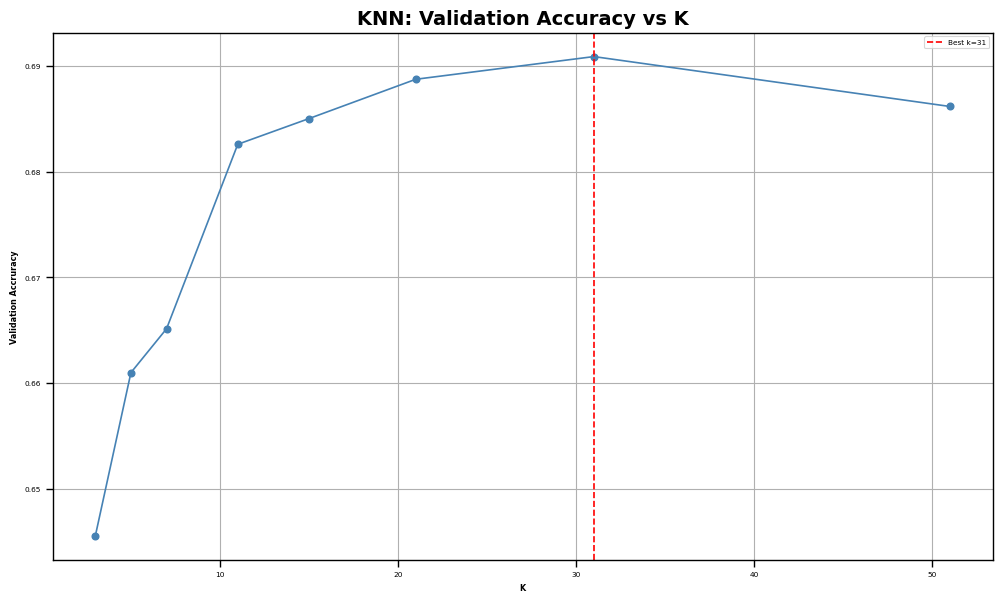

Best K: 31 with Validation Accuracy: 0.6909


In [20]:
k_values = [3,5,7,11,15,21,31,51]
knn_values = []

for k in k_values: 
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train)
    knn_values.append(accuracy_score(y_val, knn.predict(X_val_s)))

best_k = k_values[knn_values.index(max(knn_values))]

plt.figure(figsize=(10,6))
plt.plot(k_values, knn_values, marker='o', color='steelblue')
plt.axvline(best_k, color='red', linestyle='--', label=f'Best k={best_k}')
plt.xlabel('K', weight='bold')
plt.ylabel('Validation Accruracy', weight='bold')
plt.title('KNN: Validation Accuracy vs K', fontsize=14, weight='bold')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print(f'Best K: {best_k} with Validation Accuracy: {max(knn_values):.4f}')


In [21]:
knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_s, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",31
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None



  Training and validation Result table for KNN
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  k=31                     Training     0.7072  0(0.9529)  0(0.6889)  0(0.7997)  0(0.9529)  0(0.3175)  0(0.7993)
                                                1(0.3175)  1(0.8094)  1(0.4561)  1(0.3175)  1(0.9529)  1(0.7993)

  k=31                   Validation     0.6909  0(0.9448)  0(0.6780)  0(0.7895)  0(0.9448)  0(0.2879)  0(0.7435)
                                                1(0.2879)  1(0.7667)  1(0.4186)  1(0.2879)  1(0.9448)  1(0.7435)

  ......


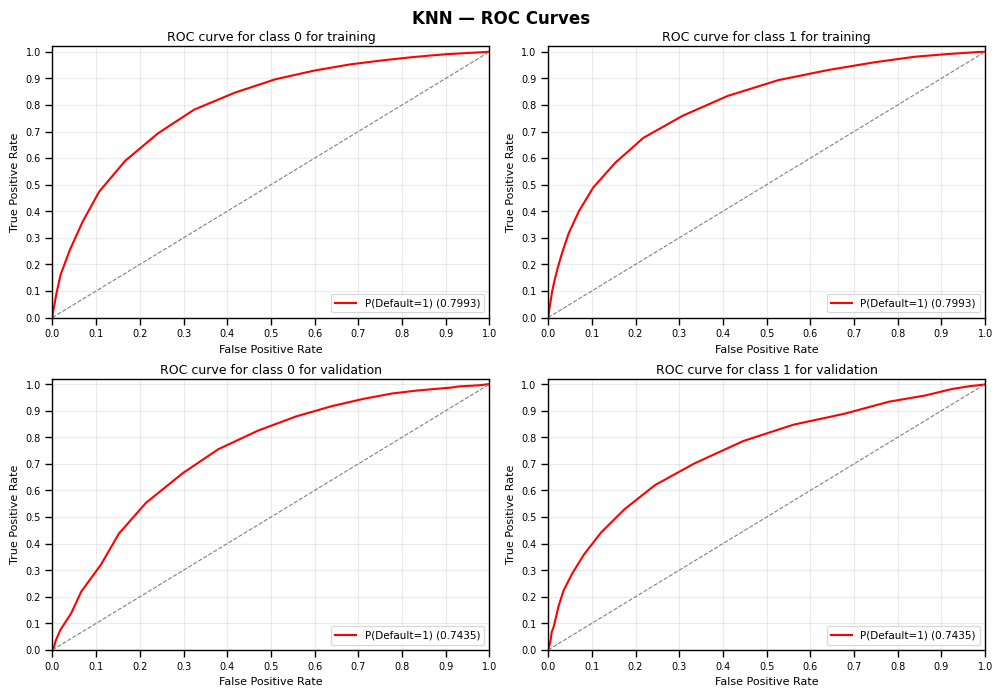

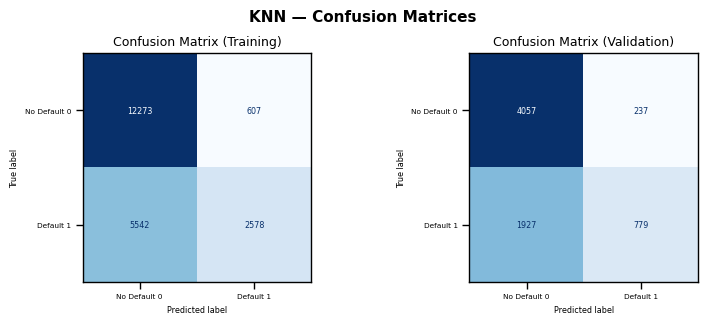

In [22]:
knn_train_m = per_class_metrics(y_train, knn_model.predict(X_train_s), knn_model.predict_proba(X_train_s)[:, 1])
knn_val_m   = per_class_metrics(y_val,   knn_model.predict(X_val_s),   knn_model.predict_proba(X_val_s)[:, 1])

full_model_report('KNN', f'k={best_k}', knn_train_m, knn_val_m)


  Test Result table for KNN
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  k=31                     Test     0.6797  0(0.9408)  0(0.6702)  0(0.7828)  0(0.9408)  0(0.2656)  0(0.7404)
                                            1(0.2656)  1(0.7390)  1(0.3908)  1(0.2656)  1(0.9408)  1(0.7404)


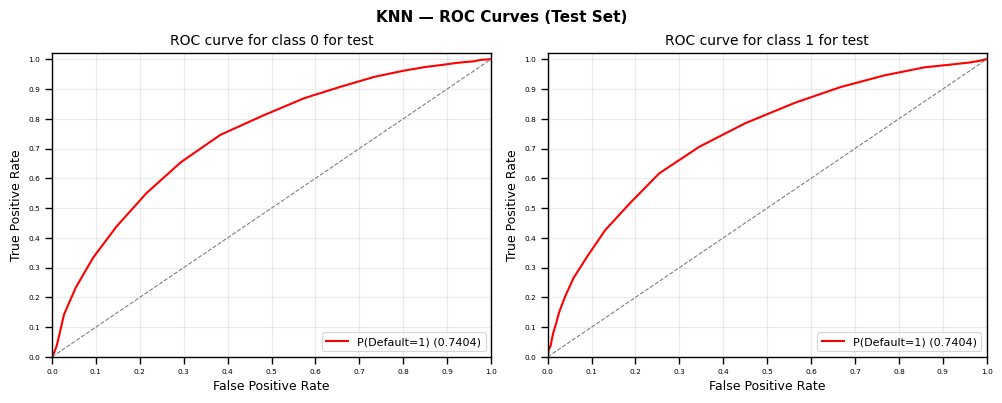

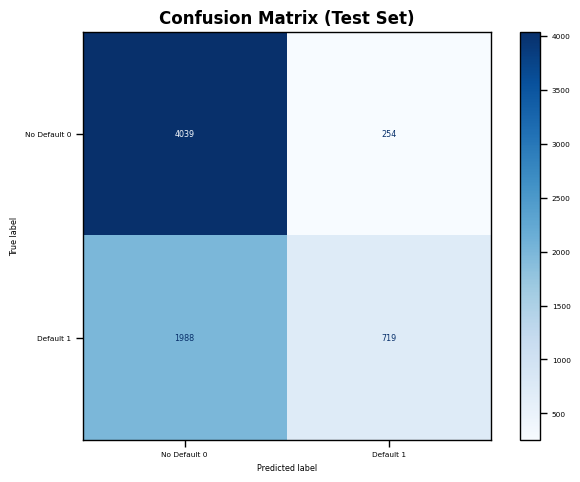

In [23]:
knn_pred = knn_model.predict(X_test_s)
knn_test = per_class_metrics(y_test, knn_pred, knn_model.predict_proba(X_test_s)[:, 1])
print_metrics_tableTest('KNN', f'k={best_k}',knn_model, X_test_s, y_test)
plot_test_roc(knn_model, X_test_s, y_test, 'KNN')   
ConfusionMatrixDisplay(knn_test['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Model 3 - Random Forest

n= 50, depth=None: value_accuracy=0.8343
n= 50, depth=10  : value_accuracy=0.8286
n= 50, depth=20  : value_accuracy=0.8357
n=100, depth=None: value_accuracy=0.8413
n=100, depth=10  : value_accuracy=0.8307
n=100, depth=20  : value_accuracy=0.8403
n=200, depth=None: value_accuracy=0.8440
n=200, depth=10  : value_accuracy=0.8344
n=200, depth=20  : value_accuracy=0.8420


<Figure size 1200x800 with 0 Axes>

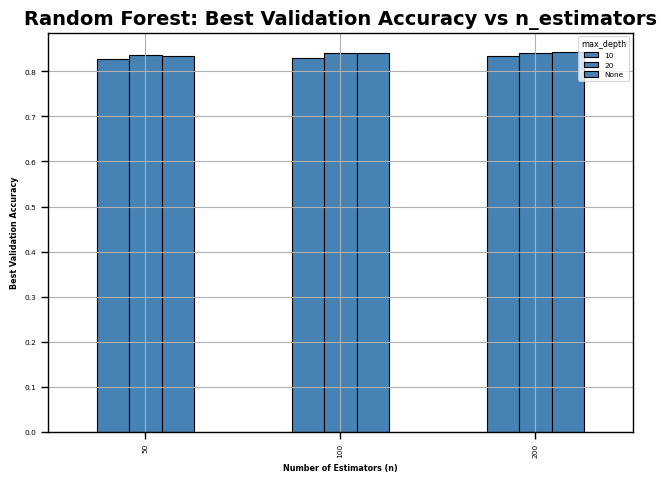


Best Random Forest: n_estimators=200, max_depth=None, value_accuracy=0.8440


In [24]:
rf_outcomes = [] # initialize an empty list to store the results of different Random Forest configurations (number of estimators and maximum depth) and their corresponding validation accuracy
for n in [50, 100, 200]: # n_estimators
    for d in [None, 10, 20]:  #max_depth
        random_forest = RandomForestClassifier(n_estimators=n, max_depth=d, random_state=42, n_jobs=-1) # create a Random Forest object with the specified n and max_depth d 
        random_forest.fit(X_train, y_train) # fit the model on the training data 
        value_accuracy = accuracy_score(y_val, random_forest.predict(X_val)) # evaluate the model on the validation set
        rf_outcomes.append({'n_estimators': n, 'max_depth': d if d is not None else 'None', 'value_accuracy': value_accuracy}) # store the results in the rf_outcomes list 
        print(f'n={n:3d}, depth={str(d):4s}: value_accuracy={value_accuracy:.4f}')
        
rf_df = pd.DataFrame(rf_outcomes) 
grouped = rf_df.groupby(['n_estimators', 'max_depth'])['value_accuracy'].mean().reset_index()
pivot = grouped.pivot(index='n_estimators', columns='max_depth', values='value_accuracy')
plt.figure(figsize=(12,8))
pivot.plot(kind='bar', color='steelblue', edgecolor='black')
plt.xlabel('Number of Estimators (n)', weight='bold')
plt.ylabel('Best Validation Accuracy', weight='bold')
plt.title('Random Forest: Best Validation Accuracy vs n_estimators', fontsize=14, weight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()
best_rf = rf_df.loc[rf_df['value_accuracy'].idxmax()]
print(f'\nBest Random Forest: n_estimators={int(best_rf.n_estimators)}, max_depth={best_rf.max_depth}, value_accuracy={best_rf.value_accuracy:.4f}')


In [25]:
max_depth_value = best_rf.max_depth 
if pd.isna(max_depth_value) or max_depth_value == "None":
    max_depth_value = None 
else: 
    max_depth_value = int(max_depth_value)
random_forest_model = RandomForestClassifier(
    n_estimators=int(best_rf.n_estimators),
    max_depth=max_depth_value,
    random_state=42, n_jobs=-1
)
random_forest_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

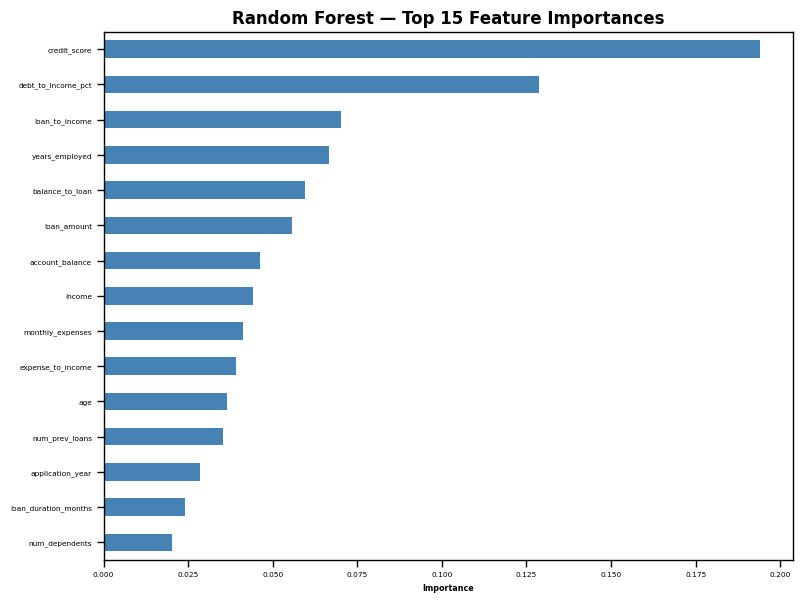

credit_score            0.193984
debt_to_income_pct      0.128727
loan_to_income          0.070075
years_employed          0.066774
balance_to_loan         0.059532
loan_amount             0.055662
account_balance         0.046335
income                  0.044043
monthly_expenses        0.041233
expense_to_income       0.039274
age                     0.036490
num_prev_loans          0.035431
application_year        0.028512
loan_duration_months    0.024154
num_dependents          0.020345
dtype: float64


In [26]:
# Feature importance
importances = pd.Series(random_forest_model.feature_importances_, index=feature_columns)
top15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
top15.sort_values().plot(kind='barh', color='steelblue')
plt.title('Random Forest — Top 15 Feature Importances', fontsize=12, weight='bold')
plt.xlabel('Importance', weight='bold')
plt.tight_layout(); plt.show()
print(top15)


  Training and validation Result table for Random Forest
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  n=200, depth= None       Training     1.0000  0(1.0000)  0(1.0000)  0(1.0000)  0(1.0000)  0(1.0000)  0(1.0000)
                                                1(1.0000)  1(1.0000)  1(1.0000)  1(1.0000)  1(1.0000)  1(1.0000)

  n=200, depth= None     Validation     0.8440  0(0.9094)  0(0.8474)  0(0.8773)  0(0.9094)  0(0.7402)  0(0.8590)
                                                1(0.7402)  1(0.8374)  1(0.7858)  1(0.7402)  1(0.9094)  1(0.8590)

  ......


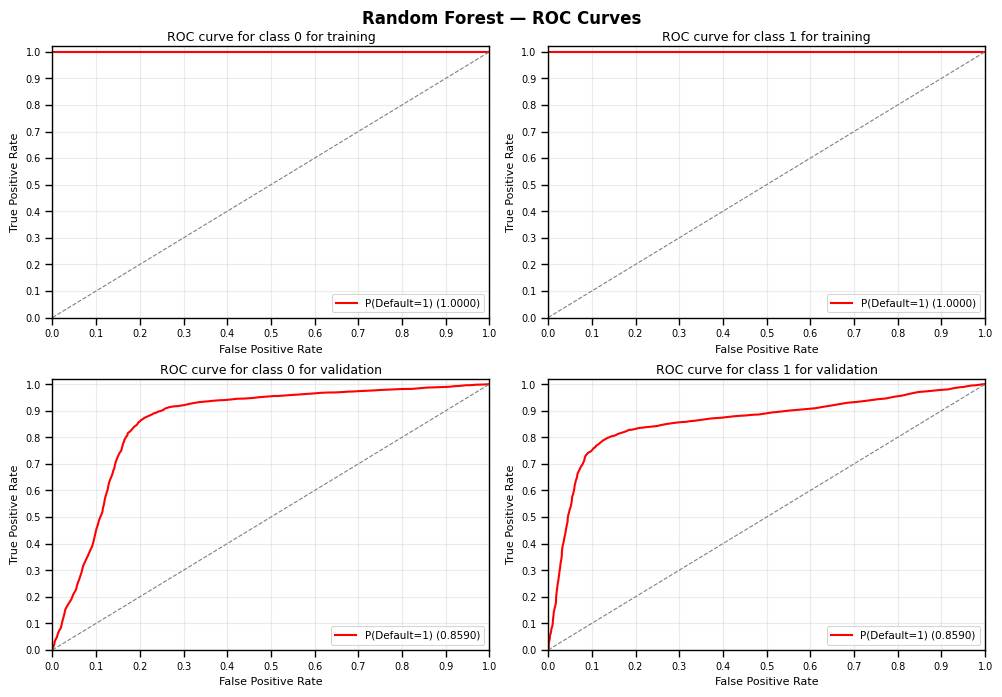

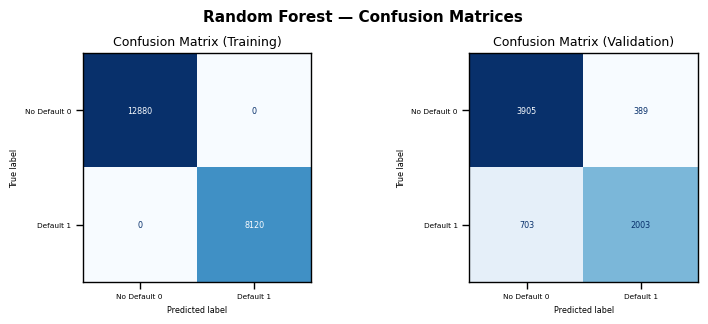

In [27]:
random_forest_model_train_m = per_class_metrics(y_train, random_forest_model.predict(X_train), random_forest_model.predict_proba(X_train)[:, 1])
random_forest_model_val_m   = per_class_metrics(y_val,   random_forest_model.predict(X_val),   random_forest_model.predict_proba(X_val)[:, 1])  
full_model_report('Random Forest', f"n={int(best_rf.n_estimators)}, depth= {best_rf.max_depth}", random_forest_model_train_m, random_forest_model_val_m)




  Test Result table for Random Forest
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  n=200, depth=None        Test     0.8350  0(0.9010)  0(0.8412)  0(0.8701)  0(0.9010)  0(0.7303)  0(0.8560)
                                            1(0.7303)  1(0.8231)  1(0.7739)  1(0.7303)  1(0.9010)  1(0.8560)


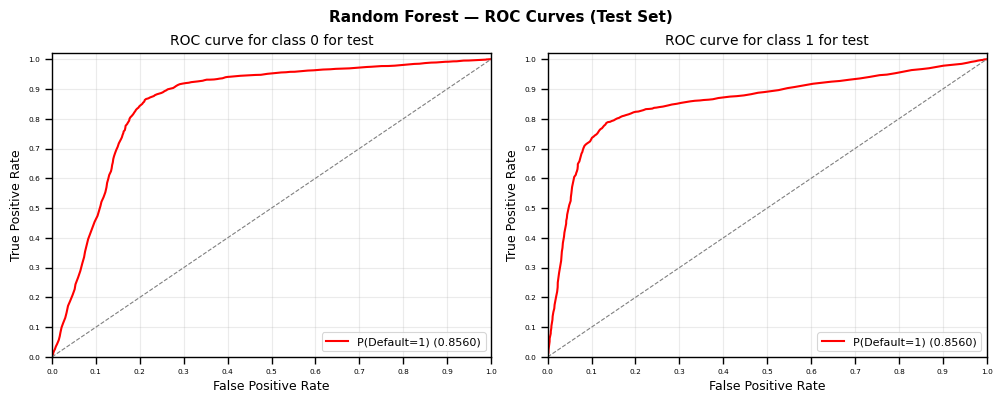

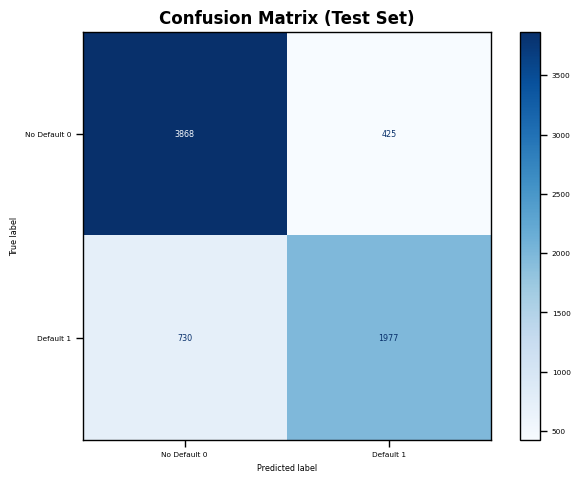

In [28]:
rf_pred = random_forest_model.predict(X_test)
rf_test = per_class_metrics(y_test, rf_pred, random_forest_model.predict_proba(X_test)[:, 1])
print_metrics_tableTest('Random Forest', f"n={int(best_rf.n_estimators)}, depth={best_rf.max_depth}", random_forest_model, X_test, y_test)
plot_test_roc(random_forest_model, X_test, y_test, 'Random Forest')
ConfusionMatrixDisplay(rf_test['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Model 4 - Support Vector Machine (NuSVC)

nu=0.1: value_accuracy=0.6969
nu=0.3: value_accuracy=0.7259
nu=0.5: value_accuracy=0.7750
nu=0.7: value_accuracy=0.7534


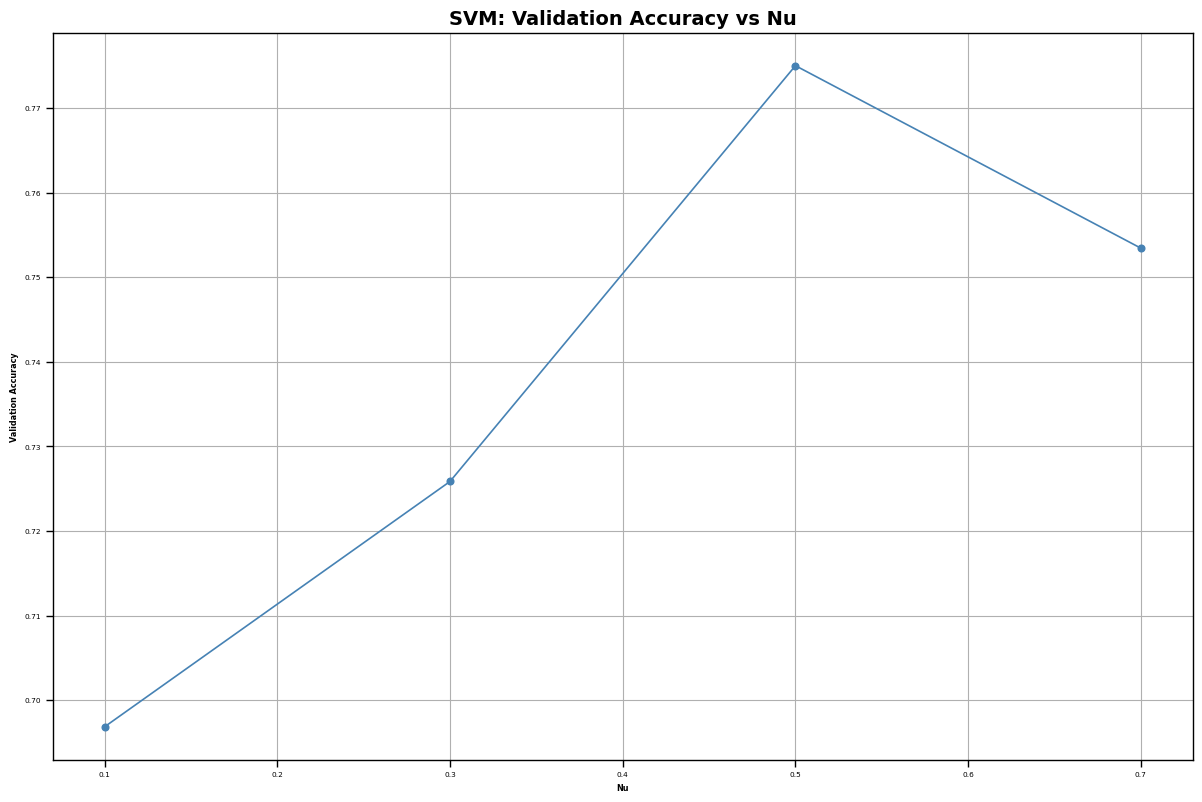


Best SVM: nu=0.5, value_accuracy=0.7750


In [29]:
from sklearn.svm import NuSVC
svm_outcomes = []
for nu in [0.1, 0.3, 0.5, 0.7]: 
    svm = NuSVC(probability=True, random_state=42, nu=nu)
    svm.fit(X_train_s, y_train)
    value_accuracy = accuracy_score(y_val, svm.predict(X_val_s))
    svm_outcomes.append({'nu': nu, 'value_accuracy': value_accuracy})
    print(f'nu={nu:.1f}: value_accuracy={value_accuracy:.4f}')
    
svm_df = pd.DataFrame(svm_outcomes)
grouped_svm = svm_df.groupby('nu')['value_accuracy'].mean().reset_index()
plt.figure(figsize=(12,8))
plt.plot(grouped_svm['nu'], grouped_svm['value_accuracy'], marker='o', color='steelblue')
plt.xlabel('Nu', weight='bold')
plt.ylabel('Validation Accuracy', weight='bold')        
plt.title('SVM: Validation Accuracy vs Nu', fontsize=14, weight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()
best_svm = svm_df.loc[svm_df['value_accuracy'].idxmax()]
print(f'\nBest SVM: nu={best_svm.nu:.1f}, value_accuracy={best_svm.value_accuracy:.4f}')



In [30]:

svm_model = NuSVC(probability=True, random_state=42, nu=best_svm.nu)
svm_model.fit(X_train_s, y_train)


,"nu nu: float, default=0.5An upper bound on the fraction of margin errors (see :ref:`User Guide`) and a lower bound of the fraction of support vectors.Should be in the interval (0, 1].",np.float64(0.5)
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: {dict, 'balanced'}, default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one. The ""balanced"" mode uses the values of y to automaticallyadjust weights inversely proportional to class frequencies as``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False



  Training and validation Result table for SVM
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  nu=0.5                   Training     0.8594  0(0.9295)  0(0.8542)  0(0.8902)  0(0.9295)  0(0.7483)  0(0.9123)
                                                1(0.7483)  1(0.8700)  1(0.8046)  1(0.7483)  1(0.9295)  1(0.9123)

  nu=0.5                 Validation     0.7750  0(0.8684)  0(0.7869)  0(0.8256)  0(0.8684)  0(0.6268)  0(0.8146)
                                                1(0.6268)  1(0.7501)  1(0.6829)  1(0.6268)  1(0.8684)  1(0.8146)

  ......


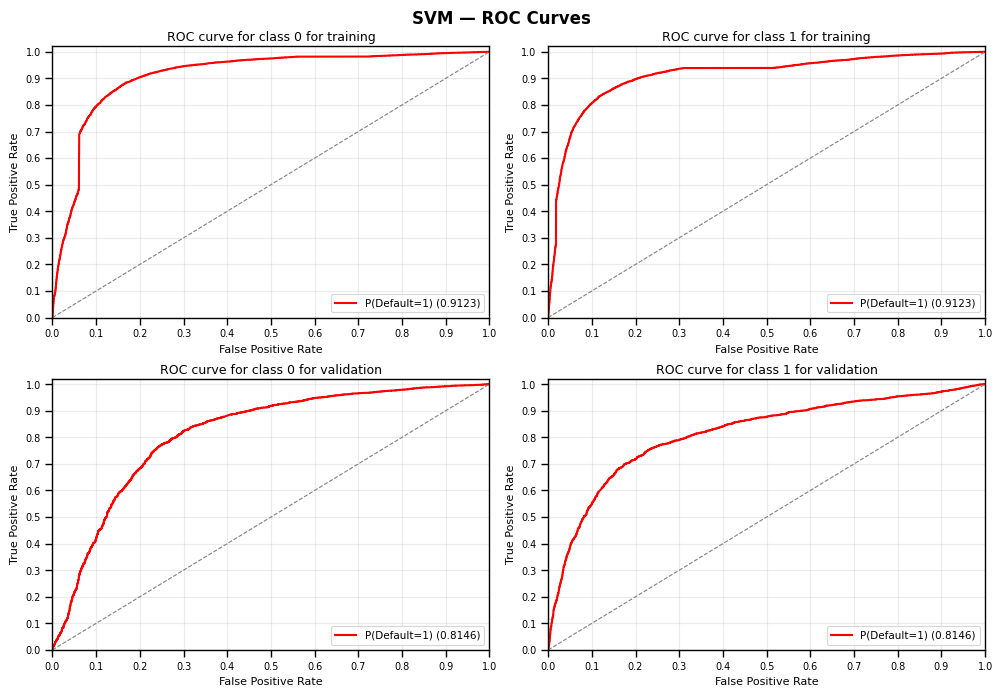

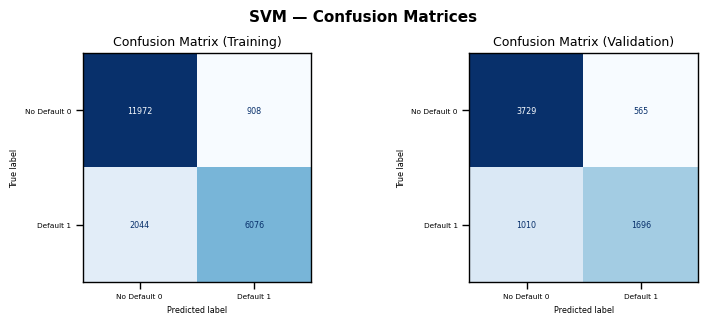

In [31]:
svm_train_m = per_class_metrics(y_train, svm_model.predict(X_train_s), svm_model.predict_proba(X_train_s)[:, 1])
svm_val_m   = per_class_metrics(y_val,   svm_model.predict(X_val_s),   svm_model.predict_proba(X_val_s)[:, 1])  
full_model_report('SVM', f'nu={best_svm.nu:.1f}', svm_train_m, svm_val_m)


  Test Result table for SVM
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  nu=0.5                   Test     0.7659  0(0.8581)  0(0.7815)  0(0.8180)  0(0.8581)  0(0.6195)  0(0.8111)
                                            1(0.6195)  1(0.7336)  1(0.6717)  1(0.6195)  1(0.8581)  1(0.8111)


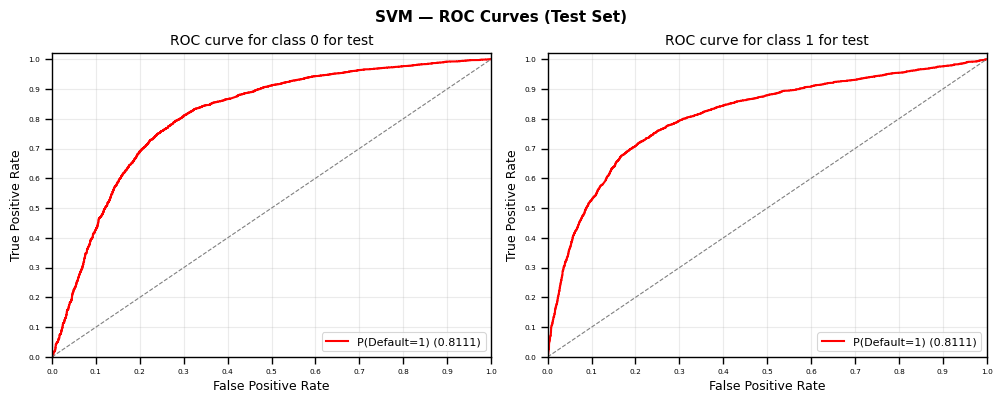

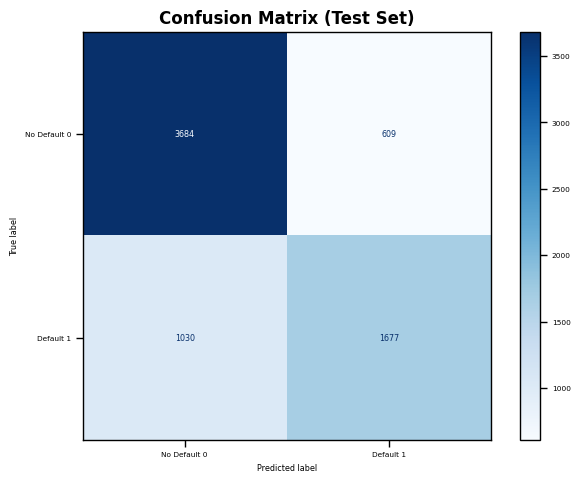

In [32]:
svm_pred = svm_model.predict(X_test_s)
svm_test = per_class_metrics(y_test, svm_pred, svm_model.predict_proba(X_test_s)[:, 1])
print_metrics_tableTest('SVM', f'nu={best_svm.nu:.1f}', svm_model, X_test_s, y_test)
plot_test_roc(svm_model, X_test_s, y_test, 'SVM')
ConfusionMatrixDisplay(svm_test['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Model 5 - Neural Network (MLP)
- Tuning the network architecture (hidden layer sizes) using the validation set

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Small layer: value_accuracy=0.7559
Medium layer: value_accuracy=0.7006
Large layer: value_accuracy=0.7091


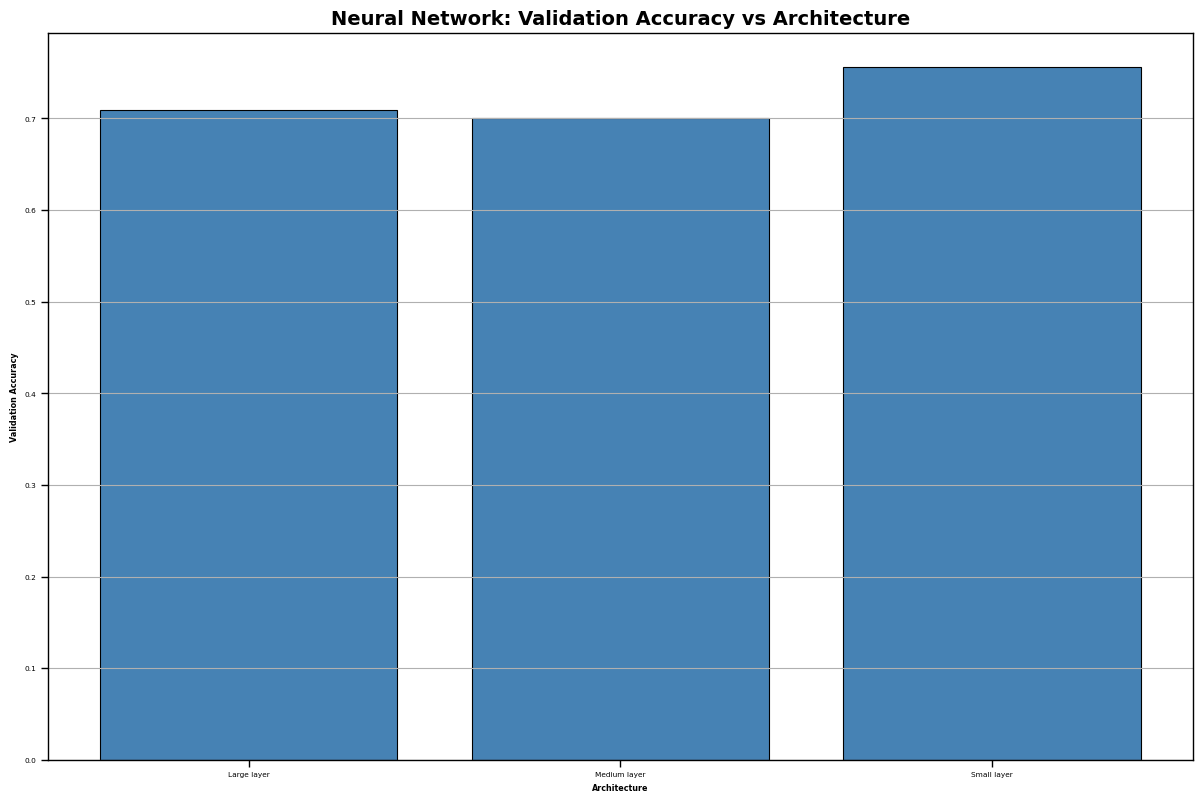


 Best Neural Network: architecture= Small layer, value_accuracy=0.7559


In [33]:
architectures = {
    'Small layer': (64,),  # default architecture with 1 hidden layer 
    'Medium layer': (128, 64),  # 2 hidden layers with 128 and 64 neurons
    'Large layer': (128, 64, 32),  # 3 hidden layers with decreasing neurons
}

nn_outcomes = []
for name, layers in architectures.items(): 
    nn = MLPClassifier(hidden_layer_sizes=layers, max_iter=300, random_state=42)
    nn.fit(X_train_s, y_train)
    value_accuracy = accuracy_score(y_val, nn.predict(X_val_s))
    nn_outcomes.append({'architecture': name, 'layers':layers, 'value_accuracy': value_accuracy})
    print(f'{name}: value_accuracy={value_accuracy:.4f}')
    
nn_df = pd.DataFrame(nn_outcomes)
grouped_nn = nn_df.groupby('architecture')['value_accuracy'].mean().reset_index()       
plt.figure(figsize=(12,8))
plt.bar(grouped_nn['architecture'], grouped_nn['value_accuracy'], color='steelblue', edgecolor='black')
plt.xlabel('Architecture', weight='bold')
plt.ylabel('Validation Accuracy', weight='bold')
plt.title('Neural Network: Validation Accuracy vs Architecture', fontsize=14, weight='bold')
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()
best_nn = nn_df.loc[nn_df['value_accuracy'].idxmax()]
best_layers = best_nn['layers']
print(f'\n Best Neural Network: architecture= {best_nn.architecture}, value_accuracy={best_nn.value_accuracy:.4f}')


In [34]:
neural_network_model = MLPClassifier(hidden_layer_sizes=best_layers, max_iter=300, random_state=42)
neural_network_model.fit(X_train_s, y_train)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",300
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42



  Training and validation Result table for Neural Network
Parameter                             Accuracy      Recall   Precision    F1 Score  Sensitivity  Specificity         AUC
-----------------------------------------------------------------------------------------------
  arch=(64,)               Training     0.8354  0(0.9002)  0(0.8423)  0(0.8703)  0(0.9002)  0(0.7328)  0(0.8977)
                                                1(0.7328)  1(0.8223)  1(0.7749)  1(0.7328)  1(0.9002)  1(0.8977)

  arch=(64,)             Validation     0.7559  0(0.8319)  0(0.7835)  0(0.8070)  0(0.8319)  0(0.6353)  0(0.8002)
                                                1(0.6353)  1(0.7042)  1(0.6680)  1(0.6353)  1(0.8319)  1(0.8002)

  ......


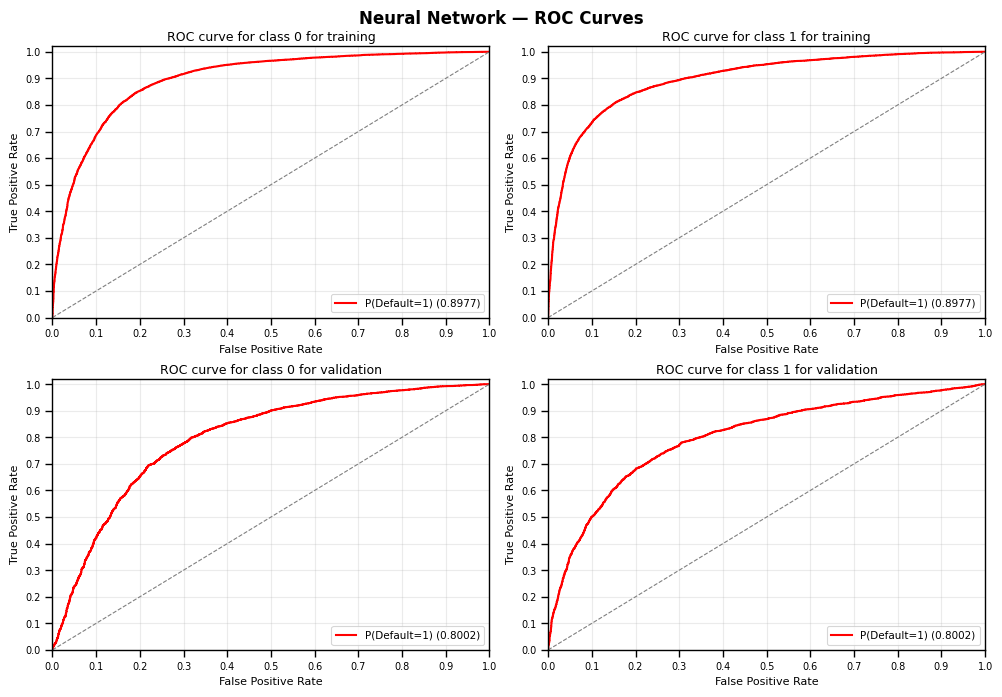

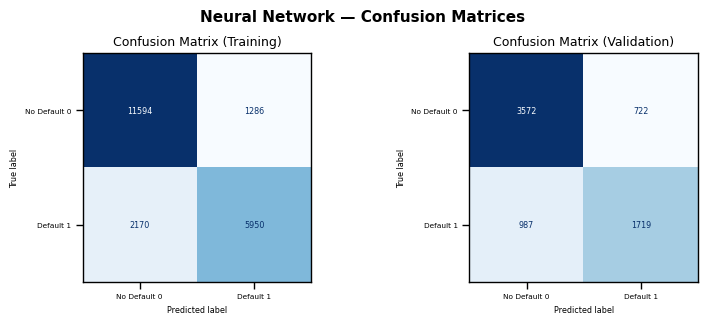

In [35]:
nn_train_m = per_class_metrics(y_train, neural_network_model.predict(X_train_s), neural_network_model.predict_proba(X_train_s)[:, 1])
nn_val_m   = per_class_metrics(y_val,   neural_network_model.predict(X_val_s),   neural_network_model.predict_proba(X_val_s)[:, 1])  
full_model_report('Neural Network', f"arch={best_nn['layers']}", nn_train_m, nn_val_m)


  Test Result table for Neural Network
Parameter                         Accuracy        Recall     Precision      F1 Score   Sensitivity   Specificity           AUC
-----------------------------------------------------------------------------------------------
  arch=(64,)               Test     0.7529  0(0.8288)  0(0.7815)  0(0.8044)  0(0.8288)  0(0.6324)  0(0.7939)
                                            1(0.6324)  1(0.6996)  1(0.6643)  1(0.6324)  1(0.8288)  1(0.7939)


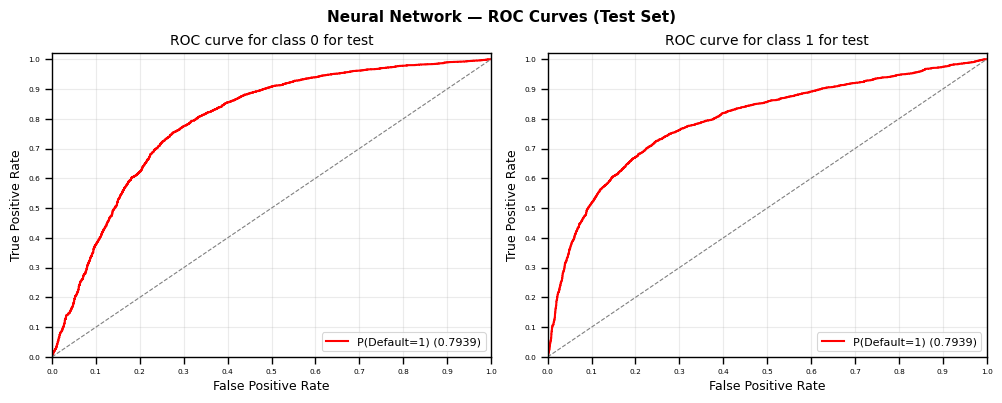

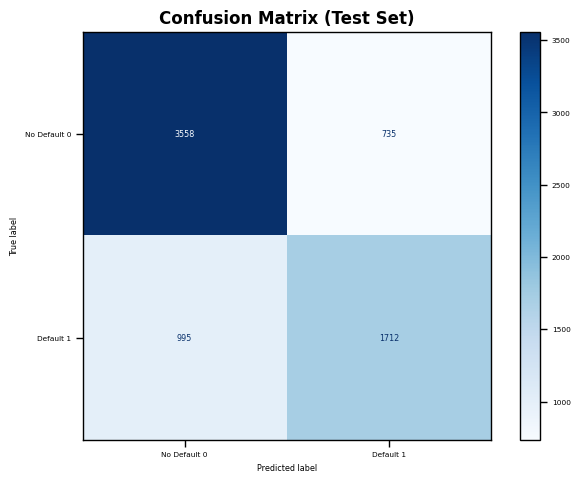

In [36]:
nn_pred = neural_network_model.predict(X_test_s)
nn_test = per_class_metrics(y_test, nn_pred, neural_network_model.predict_proba(X_test_s)[:, 1])
print_metrics_tableTest('Neural Network', f"arch={best_nn['layers']}", neural_network_model, X_test_s, y_test )
plot_test_roc(neural_network_model, X_test_s, y_test, 'Neural Network')
ConfusionMatrixDisplay(nn_test['cm'], display_labels=['No Default 0', 'Default 1']).plot(cmap='Blues')
plt.title('Confusion Matrix (Test Set)', fontsize=12, weight='bold')
plt.tight_layout()
plt.show()

## Model Comparison on Test Set

In [37]:
all_models = { 
    'Decision Tree (Gini)': (decision_tree_predG, f'max_depth={best_depth}'),
    'Decision Tree (Entropy)': (decision_tree_predE, f'max_depth={best_depth}'),
    'KNN': (knn_pred, f'k={best_k}'),
    'Random Forest': (rf_pred, f"n={int(best_rf.n_estimators)}, depth={best_rf.max_depth}"),
    'SVM': (svm_pred, f'nu={best_svm.nu}'),
    'Neural Network': (nn_pred, f"arch={best_nn['layers']}"),
}

rows = []
for name, (pred, param) in all_models.items(): 
    m = per_class_metrics(y_test, pred, random_forest_model.predict_proba(X_test_s)[:, 1])
    rows.append({
        'Model': name,
        'Parameter': param,
        'Accuracy': f"{m['acc']:.4f}",
        '0 Recall': f"{m['c0']['recall']:.4f}",
        '0 Precision': f"{m['c0']['precision']:.4f}",
        '0 F1 Score': f"{m['c0']['f1']:.4f}",
        '0 Sensitivity': f"{m['c0']['sensitivity']:.4f}",
        '0 Specificity': f"{m['c0']['specificity']:.4f}",
        '0 AUC': f"{m['c0']['auc']:.4f}",
        '1 Recall': f"{m['c1']['recall']:.4f}",
        '1 Precision': f"{m['c1']['precision']:.4f}",
        '1 F1 Score': f"{m['c1']['f1']:.4f}",
        '1 Sensitivity': f"{m['c1']['sensitivity']:.4f}",
        '1 Specificity': f"{m['c1']['specificity']:.4f}",
        '1 AUC': f"{m['c1']['auc']:.4f}"
    })
    
comparision = pd.DataFrame(rows).sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparision.to_string(index=False))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.

                  Model         Parameter Accuracy 0 Recall 0 Precision 0 F1 Score 0 Sensitivity 0 Specificity  0 AUC 1 Recall 1 Precision 1 F1 Score 1 Sensitivity 1 Specificity  1 AUC
Decision Tree (Entropy)       max_depth=9   0.8350   0.9110      0.8350     0.8713        0.9110        0.7144 0.5214   0.7144      0.8351     0.7701        0.7144        0.9110 0.5214
          Random Forest n=200, depth=None   0.8350   0.9010      0.8412     0.8701        0.9010        0.7303 0.5214   0.7303      0.8231     0.7739        0.7303        0.9010 0.5214
   Decision Tree (Gini)       max_depth=9   0.8314   0.9068      0.8331     0.8684        0.9068        0.7119 0.5214   0.7119      0.8281     0.7656        0.7119        0.9068 0.5214
                    SVM            nu=0.5   0.7659   0.8581      0.7815     0.8180        0.8581        0.6195 0.5214   0.6195      0.7336     0.6717        0.6195        0.8581 0.5214
         Neural Network        arch=(64,)   0.7529   0.8288      0.7815    

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


## Process Unknown Dataset & Generate Kaggle Submissions

In [38]:
unknown_data = pd.read_csv("/Users/wendycs037/Desktop/introtoData/A3_Assignment/Assignment3-Unknown-Dataset.csv")
print(unknown_data.head())
unknown_clean, _ = preprocess(unknown_data, fit_medians=train_medians, fit_columns=X.columns.tolist())
print('Unknown preprocessed shape:', unknown_clean.shape)
print('Any missing values in unknown data after preprocessing:', unknown_clean.isnull().sum().sum())

unknown_pred_RF = random_forest_model.predict(unknown_clean)
print(pd.Series(unknown_pred_RF).value_counts())
submission_RF = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_RF))],
    'Predicted-Loan-Default': unknown_pred_RF
})
submission_RF.to_csv('submission_RF.csv', index=False)

unknown_pred_dtG = decision_tree_modelG.predict(unknown_clean)
print(pd.Series(unknown_pred_dtG).value_counts())
submission_dtG = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_dtG))],
    'Predicted-Loan-Default': unknown_pred_dtG
})
submission_dtG.to_csv('submission_dt_gini.csv', index=False)

unknown_pred_dtE = decision_tree_modelE.predict(unknown_clean)
print(pd.Series(unknown_pred_dtE).value_counts())
submission_dtE = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_dtE))],
    'Predicted-Loan-Default': unknown_pred_dtE
})
submission_dtE.to_csv('submission_dt_entropy.csv', index=False)

unknown_pred_knn = knn_model.predict(scaler.transform(unknown_clean))
print(pd.Series(unknown_pred_knn).value_counts())
submission_knn = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_knn))],
    'Predicted-Loan-Default': unknown_pred_knn
})
submission_knn.to_csv('submission_knn.csv', index=False)

unknown_pred_svm = svm_model.predict(scaler.transform(unknown_clean))
print(pd.Series(unknown_pred_svm).value_counts())
submission_svm = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_svm))],
    'Predicted-Loan-Default': unknown_pred_svm
})
submission_svm.to_csv('submission_svm.csv', index=False)

unknown_pred_nn = neural_network_model.predict(scaler.transform(unknown_clean))
print(pd.Series(unknown_pred_nn).value_counts())
submission_nn = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(unknown_pred_nn))],
    'Predicted-Loan-Default': unknown_pred_nn
})
submission_nn.to_csv('submission_nn.csv', index=False)

   age    income  credit_score  loan_amount  debt_to_income_pct  \
0   25  17702.98           728     10219.75               21.34   
1   56  40237.65           677      9830.17               33.47   
2   28  86411.51           650     36074.35               67.85   
3   70  36382.46           544     40899.06               35.50   
4   53  49737.48           502      7423.23               12.35   

   num_dependents  years_employed  account_balance  num_prev_loans  \
0             3.0            10.1          9816.53               1   
1             2.0             1.0          2083.88               3   
2             5.0             4.2         17977.31               1   
3             0.0             3.4         12344.64               8   
4             2.0             1.0           579.76               1   

   monthly_expenses  gender employment_status education_level loan_purpose  \
0           3150.60    Male         Full-Time     High School         Home   
1           8615.89 

## Model Selection and Final Training 
- **Random Forest** achieves the highest validation accuracy and AUC on the validation test. It outperforms other models because: 
1. It combines hundreds of decision trees, reducing overfitting through bagging. 
2. It uses random feature subsets at each split, adding further diversity
3. The key predictive features (`credit_score`, `debt_to_income_pct`, `loan_amount`) are well-matched with tree-based splits 

In [39]:
# Retrain on full dataset
final_model = RandomForestClassifier(n_estimators=int(best_rf.n_estimators), max_depth=max_depth_value, random_state=42, n_jobs=-1)
final_model.fit(X, y)       
final_pred = final_model.predict(unknown_clean)
print(pd.Series(final_pred).value_counts()) 
final_submission = pd.DataFrame({
    'row ID': [f'Row{i}' for i in range(len(final_pred))],
    'Predicted-Loan-Default': final_pred
})
final_submission.to_csv('ida_a3_25419413.csv', index=False)

0    9763
1    5237
Name: count, dtype: int64
